# Claude Code Benchmark Analysis
## Comparing Language Modes Across 18 Scripting Tasks

**Benchmark**: 144 runs (18 tasks x 4 modes x 2 models)  
**Models**: Claude Opus 4.6, Claude Sonnet 4.6  
**Modes**: default (agent's choice), powershell, powershell-strict, csharp-script  
**Total cost**: ~$437

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 110

# Load the summary
with open("results/2026-04-02_163146/summary.json") as f:
    summary = json.load(f)

df = pd.DataFrame(summary["tasks"])
df["duration_min"] = df["duration_s"] / 60
df["task_num"] = df["task_id"].str[:2].astype(int)
df["task_short"] = df["task_id"].str[3:].str.replace("-", " ").str.title()

# Nice display names
mode_order = ["default", "powershell", "powershell-strict", "csharp-script"]
mode_labels = {"default": "Default\n(agent's choice)", "powershell": "PowerShell", 
               "powershell-strict": "PowerShell\nStrict", "csharp-script": "C# Script"}
model_order = ["opus", "sonnet"]

print(f"Loaded {len(df)} runs across {df['task_id'].nunique()} tasks")
print(f"Total cost: ${df['cost_usd'].sum():.2f}")
print(f"Total duration: {df['duration_s'].sum()/3600:.1f} hours")
df.head()

Loaded 144 runs across 18 tasks
Total cost: $436.67
Total duration: 85.0 hours


,task_id,mode,model,duration_s,cost_usd,lines,errors,language,turns,duration_min,task_num,task_short
0,01-csv-report-generator,default,opus,1429.612,4.920692,371,225,python,222,23.826867,1,Csv Report Generator
1,01-csv-report-generator,powershell,opus,685.535,3.052484,479,89,powershell,97,11.425583,1,Csv Report Generator
2,01-csv-report-generator,powershell-strict,opus,971.041,5.792698,604,176,powershell,168,16.184017,1,Csv Report Generator
3,01-csv-report-generator,csharp-script,opus,16270.690,0.000000,165,0,csharp,0,271.178167,1,Csv Report Generator
4,01-csv-report-generator,default,sonnet,3189.902,0.651817,511,25,python,37,53.165033,1,Csv Report Generator


## 1. Cost by Mode and Model

How much does each language mode cost, and how does that differ between Opus and Sonnet?

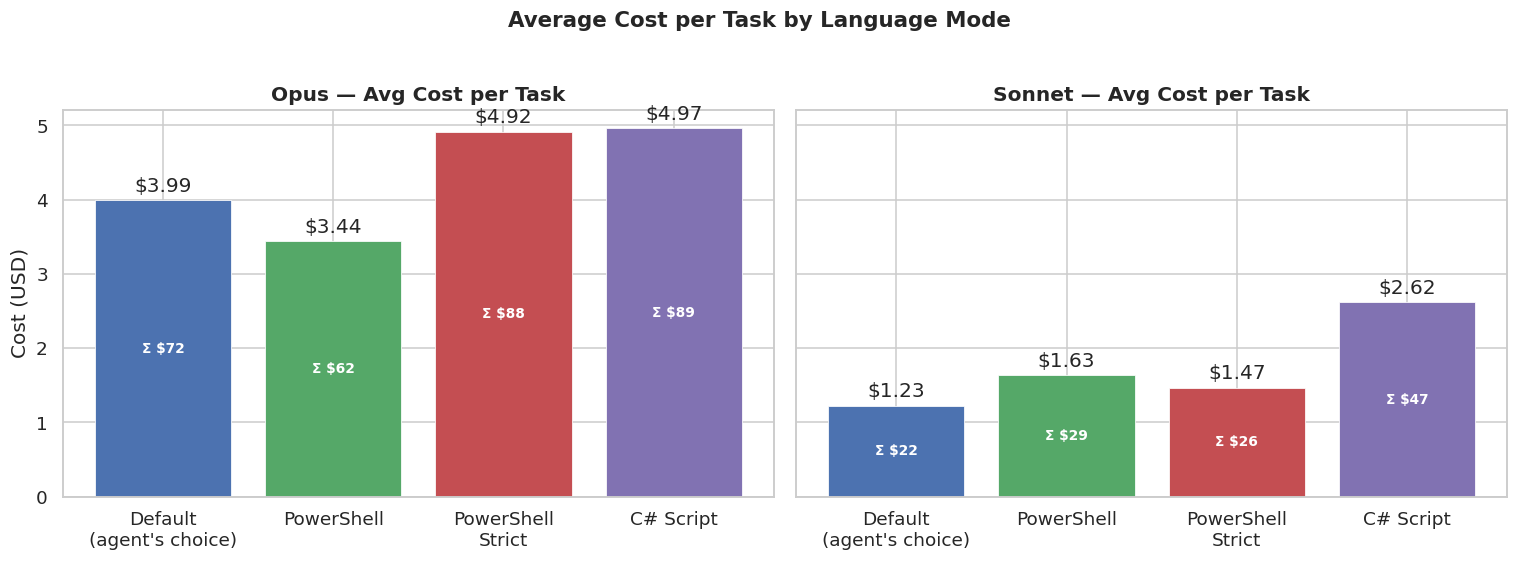

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
palette = {"default": "#4C72B0", "powershell": "#55A868", "powershell-strict": "#C44E52", "csharp-script": "#8172B2"}

for i, model in enumerate(model_order):
    ax = axes[i]
    sub = df[df["model"] == model]
    cost_by_mode = sub.groupby("mode")["cost_usd"].agg(["mean", "sum"]).reindex(mode_order)
    bars = ax.bar([mode_labels[m] for m in mode_order], cost_by_mode["mean"], 
                  color=[palette[m] for m in mode_order], edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="$%.2f", padding=3)
    ax.set_title(f"{model.title()} — Avg Cost per Task", fontweight="bold")
    ax.set_ylabel("Cost (USD)" if i == 0 else "")
    
    # Add total cost annotation
    for j, m in enumerate(mode_order):
        total = cost_by_mode.loc[m, "sum"]
        ax.text(j, cost_by_mode.loc[m, "mean"] * 0.5, f"Σ ${total:.0f}", 
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")

fig.suptitle("Average Cost per Task by Language Mode", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Duration by Mode and Model

Wall-clock time per task — how long does the agent take to complete each task?

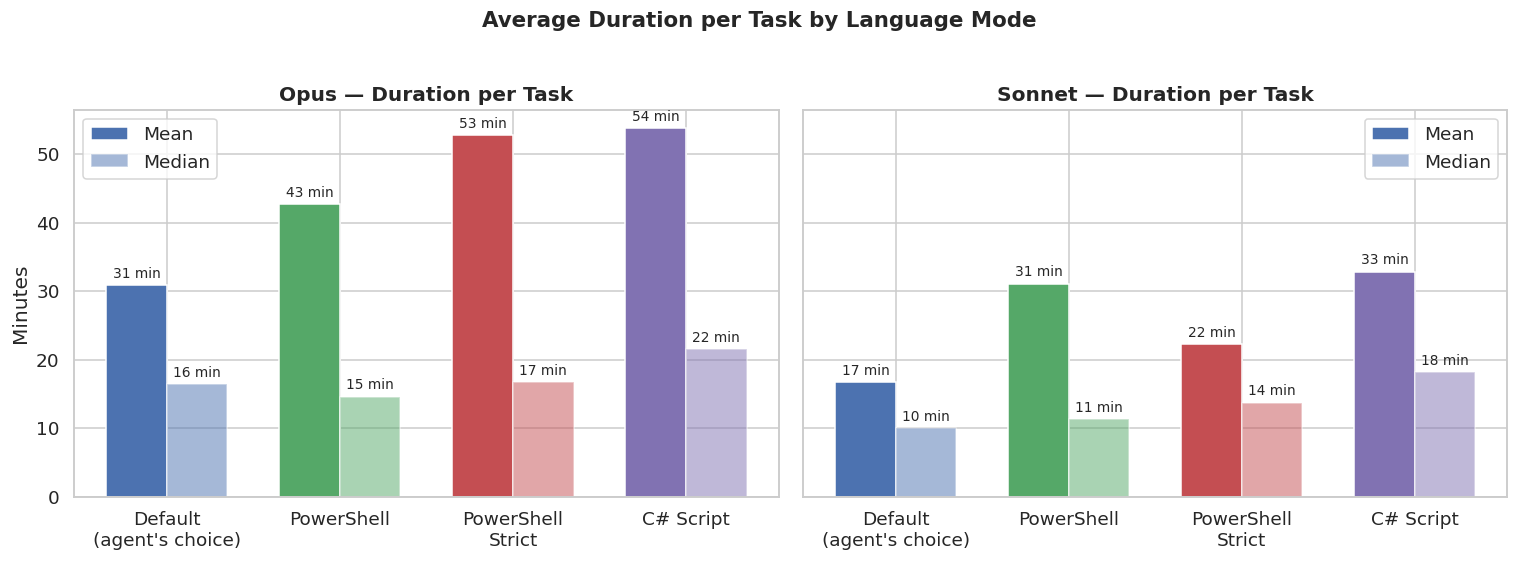

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, model in enumerate(model_order):
    ax = axes[i]
    sub = df[df["model"] == model]
    dur_by_mode = sub.groupby("mode")["duration_min"].agg(["mean", "median"]).reindex(mode_order)
    x = np.arange(len(mode_order))
    w = 0.35
    bars1 = ax.bar(x - w/2, dur_by_mode["mean"], w, label="Mean", 
                   color=[palette[m] for m in mode_order], edgecolor="white")
    bars2 = ax.bar(x + w/2, dur_by_mode["median"], w, label="Median",
                   color=[palette[m] for m in mode_order], alpha=0.5, edgecolor="white")
    ax.bar_label(bars1, fmt="%.0f min", padding=3, fontsize=9)
    ax.bar_label(bars2, fmt="%.0f min", padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([mode_labels[m] for m in mode_order])
    ax.set_title(f"{model.title()} — Duration per Task", fontweight="bold")
    ax.set_ylabel("Minutes" if i == 0 else "")
    ax.legend()

fig.suptitle("Average Duration per Task by Language Mode", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Error Rates

Number of errors encountered during each run. Higher errors generally mean more tool-permission denials or runtime failures the agent had to work through.

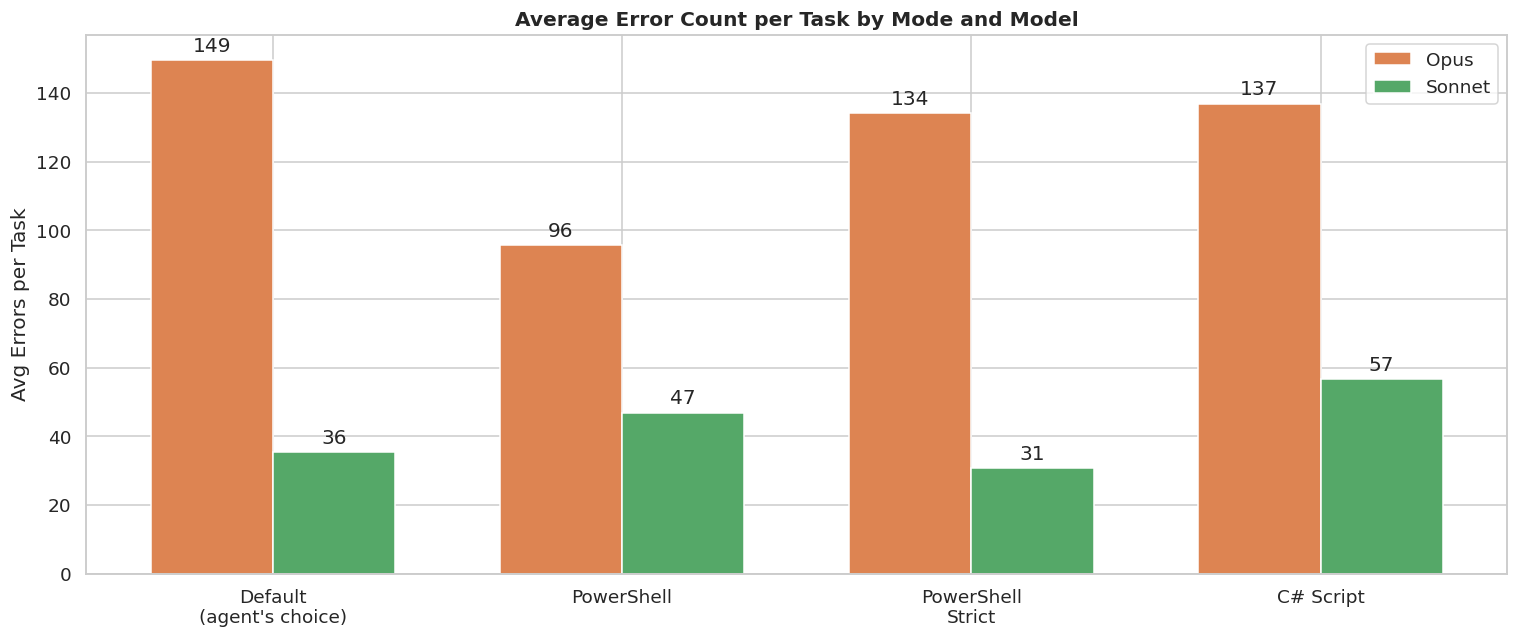

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_err = df.pivot_table(index="mode", columns="model", values="errors", aggfunc="mean").reindex(mode_order)[model_order]

x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_err["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_err["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0f", padding=3)
ax.bar_label(bars2, fmt="%.0f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Errors per Task")
ax.set_title("Average Error Count per Task by Mode and Model", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Agent Turns (Conversation Rounds)

Number of back-and-forth turns the agent needed. More turns = more iteration to reach a solution.

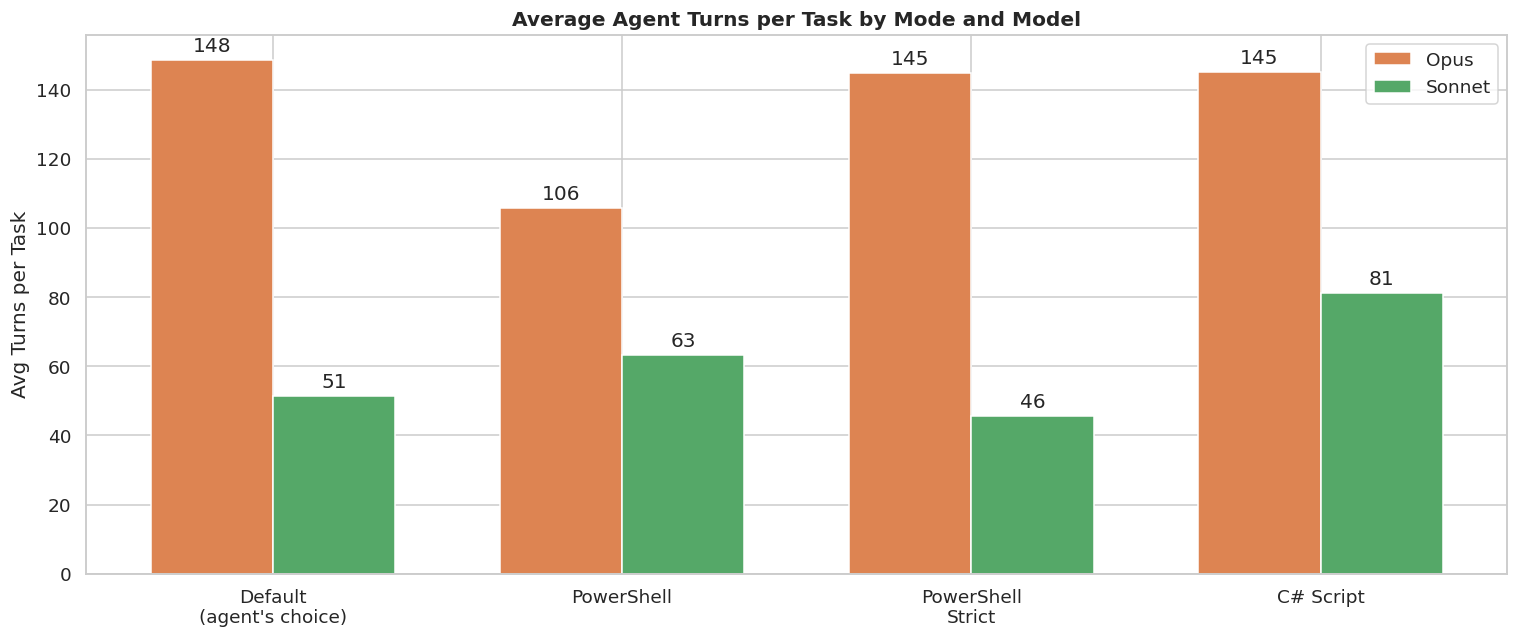

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_turns = df.pivot_table(index="mode", columns="model", values="turns", aggfunc="mean").reindex(mode_order)[model_order]

x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_turns["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_turns["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0f", padding=3)
ax.bar_label(bars2, fmt="%.0f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Turns per Task")
ax.set_title("Average Agent Turns per Task by Mode and Model", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Lines of Code Generated

How much code does each mode produce? C# tends to be more verbose.

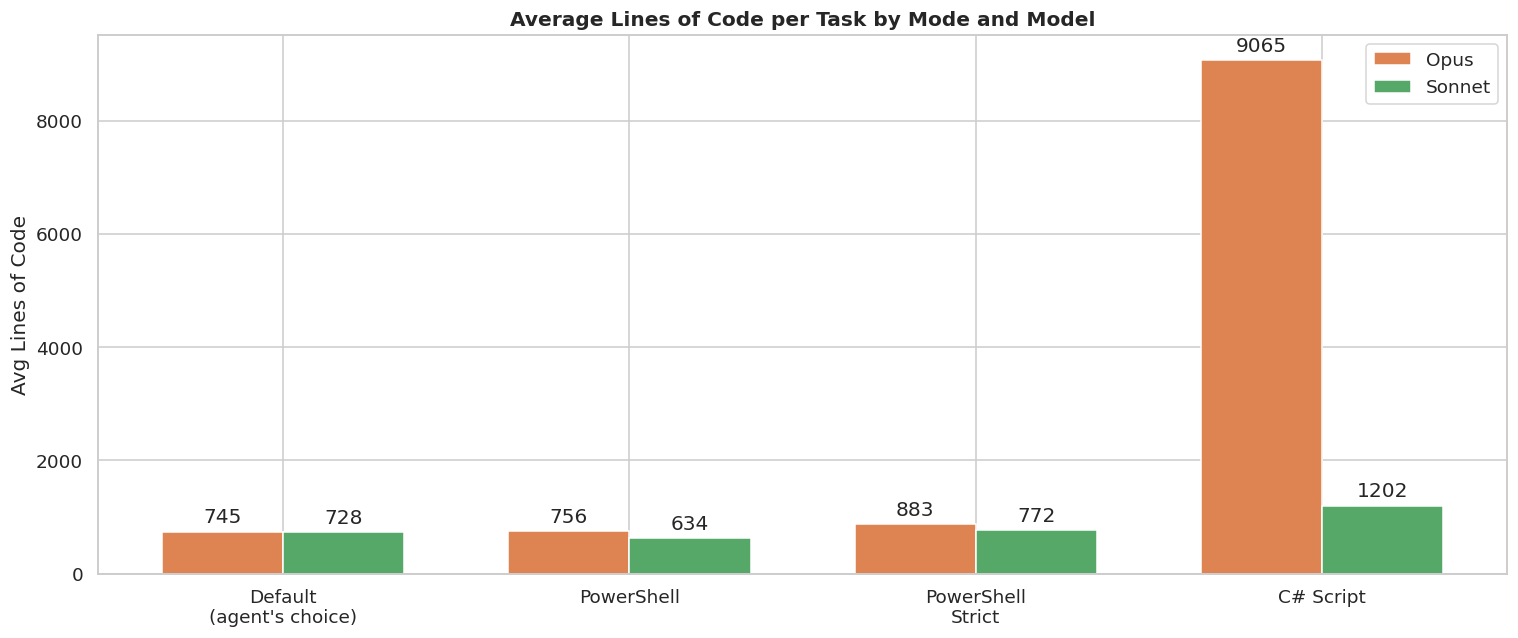

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot_lines = df.pivot_table(index="mode", columns="model", values="lines", aggfunc="mean").reindex(mode_order)[model_order]

x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_lines["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_lines["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0f", padding=3)
ax.bar_label(bars2, fmt="%.0f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Lines of Code")
ax.set_title("Average Lines of Code per Task by Mode and Model", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Cost Efficiency — Cost per Line of Code

Which mode gives you the most code for your dollar?

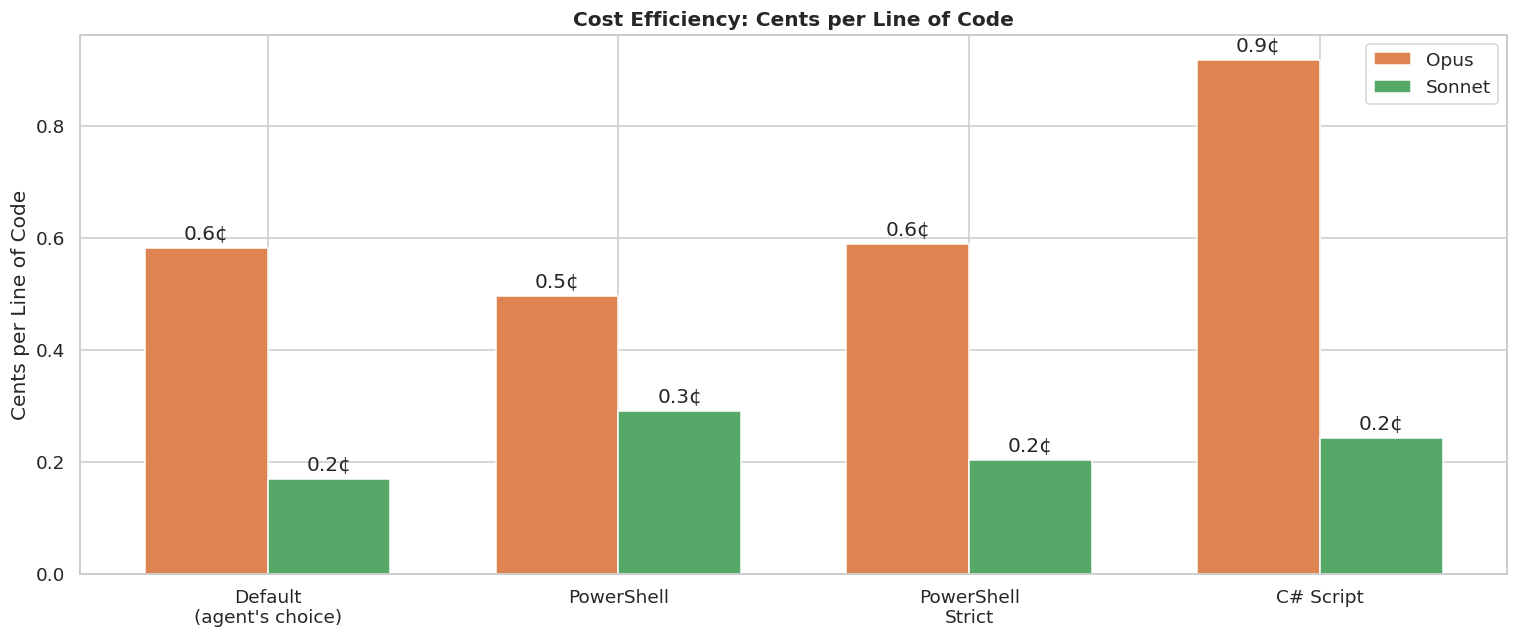

In [7]:
# Filter out runs with 0 cost (failed/stalled runs)
df_valid = df[(df["cost_usd"] > 0) & (df["lines"] > 0)].copy()
df_valid["cost_per_line"] = df_valid["cost_usd"] / df_valid["lines"] * 100  # cents per line

fig, ax = plt.subplots(figsize=(14, 6))
pivot_cpl = df_valid.pivot_table(index="mode", columns="model", values="cost_per_line", aggfunc="mean").reindex(mode_order)[model_order]

x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_cpl["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_cpl["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1f¢", padding=3)
ax.bar_label(bars2, fmt="%.1f¢", padding=3)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Cents per Line of Code")
ax.set_title("Cost Efficiency: Cents per Line of Code", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Task-Level Heatmap — Cost by Task, Mode, and Model

Which tasks are hardest (most expensive) across modes?

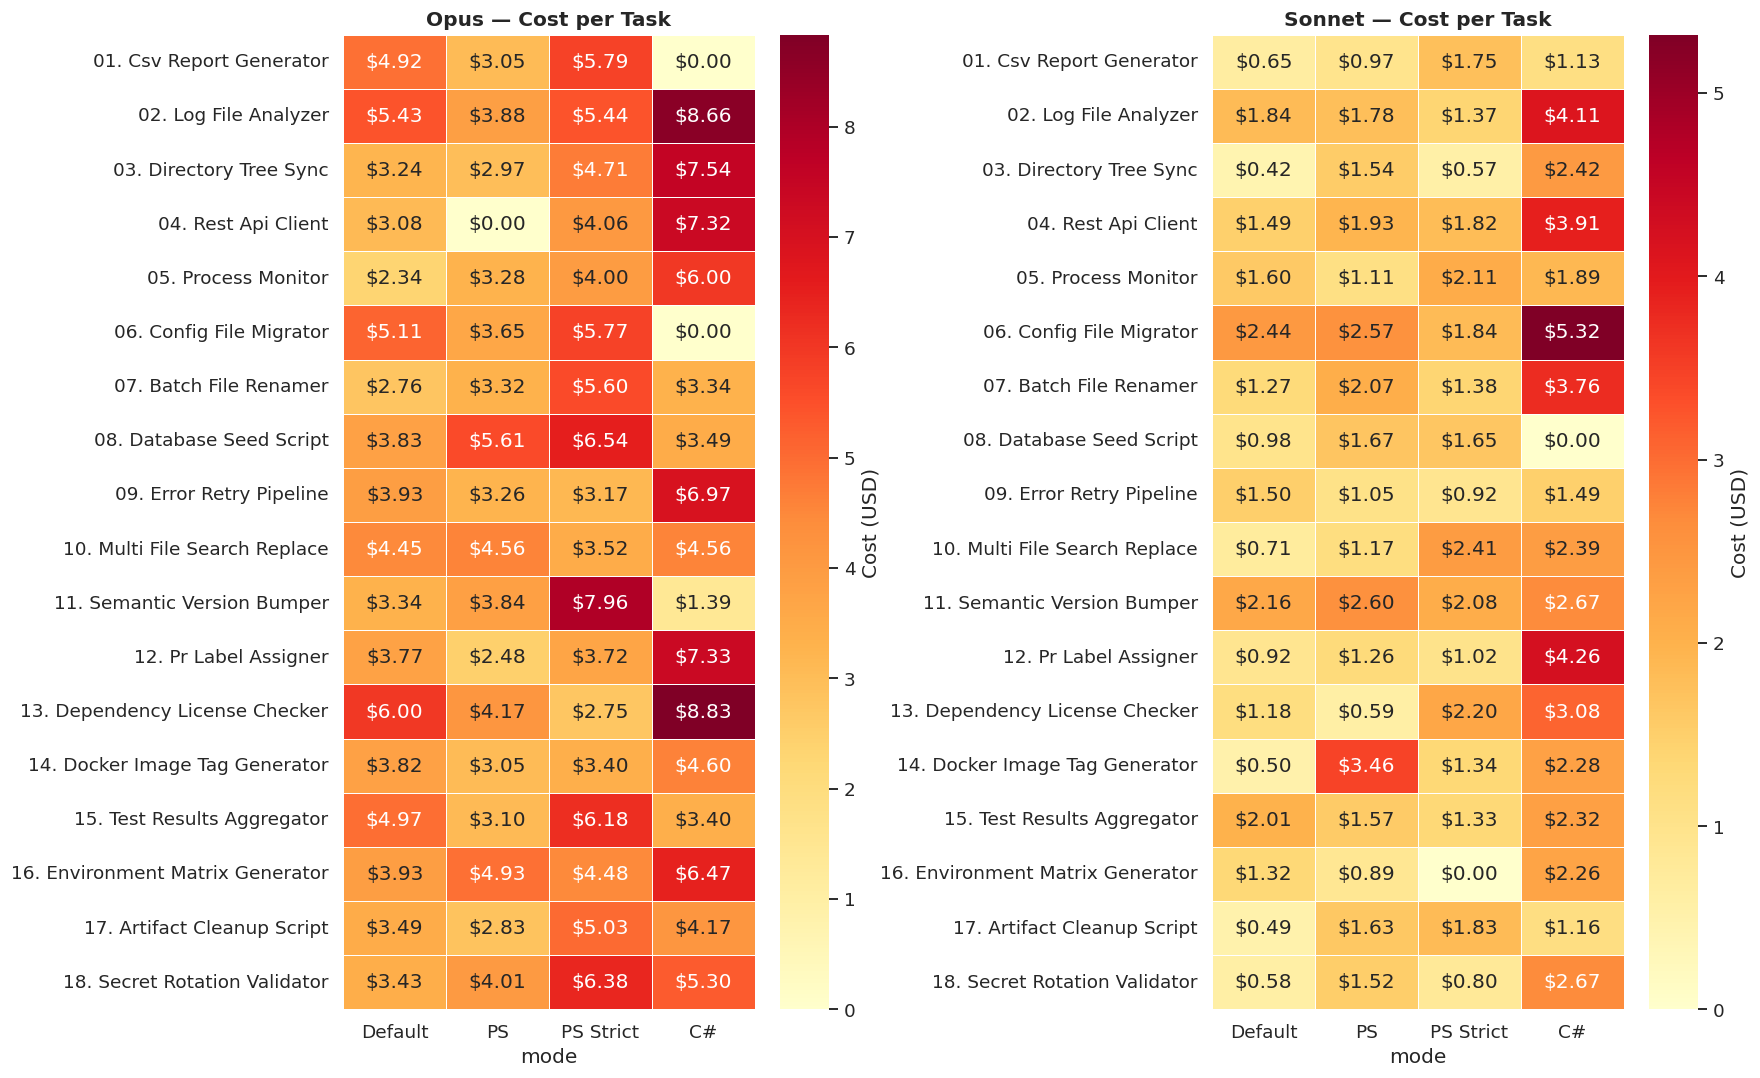

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for i, model in enumerate(model_order):
    ax = axes[i]
    sub = df[df["model"] == model]
    pivot = sub.pivot_table(index="task_id", columns="mode", values="cost_usd").reindex(columns=mode_order)
    pivot.index = [f"{tid[:2]}. {tid[3:].replace('-', ' ').title()}" for tid in pivot.index]
    
    # Create formatted annotation array (seaborn fmt doesn't support '$' prefix)
    annot_labels = pivot.map(lambda v: f"${v:.2f}" if pd.notna(v) else "")
    
    sns.heatmap(pivot, ax=ax, annot=annot_labels, fmt="", cmap="YlOrRd", 
                linewidths=0.5, cbar_kws={"label": "Cost (USD)"})
    ax.set_title(f"{model.title()} — Cost per Task", fontweight="bold")
    ax.set_ylabel("")
    ax.set_xticklabels(["Default", "PS", "PS Strict", "C#"], rotation=0)

plt.tight_layout()
plt.show()

## 8. Task-Level Heatmap — Duration by Task, Mode, and Model

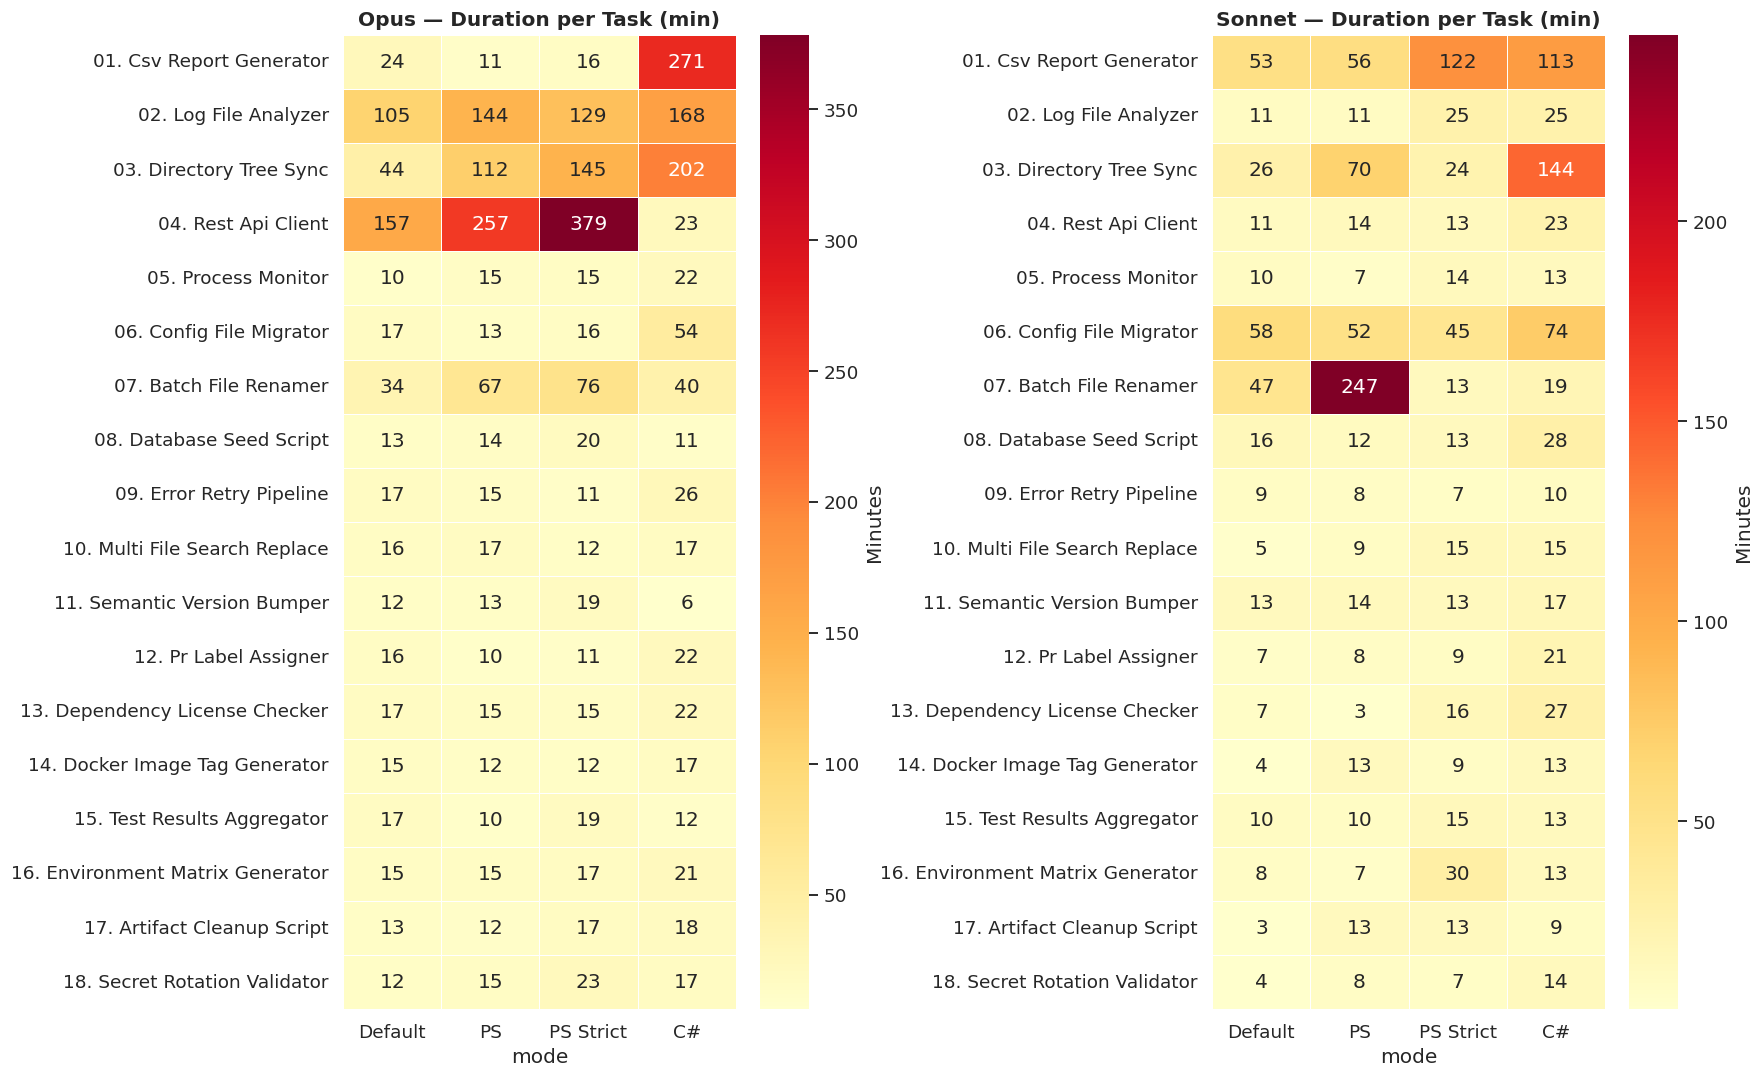

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for i, model in enumerate(model_order):
    ax = axes[i]
    sub = df[df["model"] == model]
    pivot = sub.pivot_table(index="task_id", columns="mode", values="duration_min").reindex(columns=mode_order)
    pivot.index = [f"{tid[:2]}. {tid[3:].replace('-', ' ').title()}" for tid in pivot.index]
    
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
                linewidths=0.5, cbar_kws={"label": "Minutes"})
    ax.set_title(f"{model.title()} — Duration per Task (min)", fontweight="bold")
    ax.set_ylabel("")
    ax.set_xticklabels(["Default", "PS", "PS Strict", "C#"], rotation=0)

plt.tight_layout()
plt.show()

## 9. Language Choices in Default Mode

When the agent can choose any language, what does it pick?

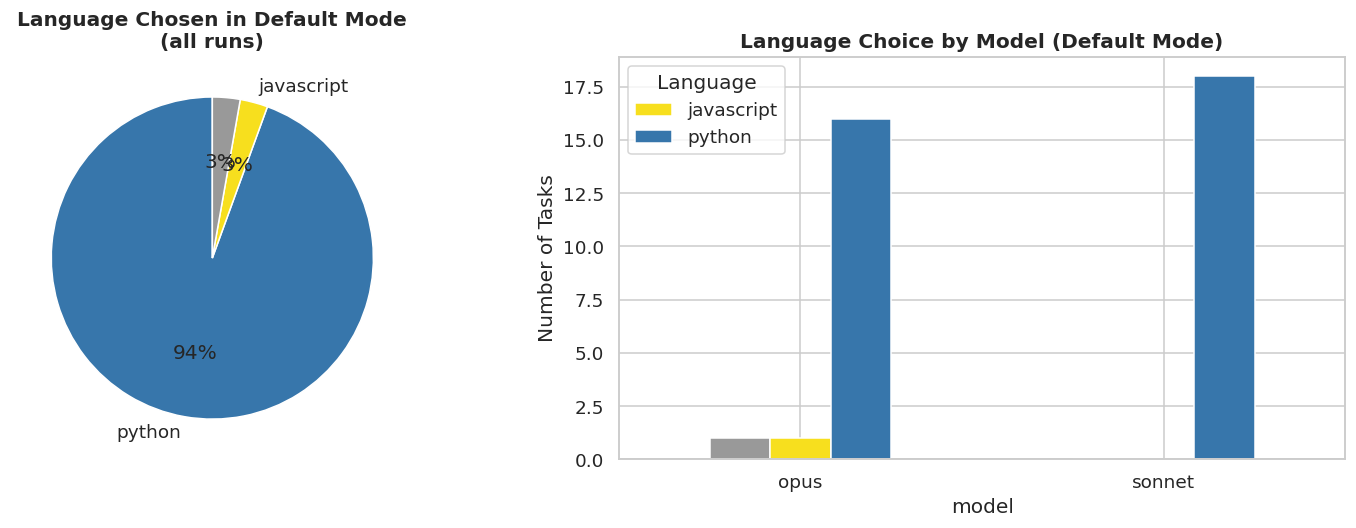


Language choices by model in default mode:
language     javascript  python
model                          
opus      1           1      16
sonnet    0           0      18


In [10]:
default_runs = df[df["mode"] == "default"]
lang_counts = default_runs["language"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_lang = {"python": "#3776AB", "javascript": "#F7DF1E", "bash": "#4EAA25", 
               "typescript": "#3178C6", "powershell": "#012456", "csharp": "#68217A"}
ax = axes[0]
ax.pie(lang_counts.values, labels=lang_counts.index, autopct="%1.0f%%", startangle=90,
       colors=[colors_lang.get(l, "#999") for l in lang_counts.index])
ax.set_title("Language Chosen in Default Mode\n(all runs)", fontweight="bold")

# By model
ax = axes[1]
lang_by_model = default_runs.groupby(["model", "language"]).size().unstack(fill_value=0)
lang_by_model.plot(kind="bar", ax=ax, color=[colors_lang.get(l, "#999") for l in lang_by_model.columns])
ax.set_title("Language Choice by Model (Default Mode)", fontweight="bold")
ax.set_ylabel("Number of Tasks")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Language")

plt.tight_layout()
plt.show()

# Detail table
print("\nLanguage choices by model in default mode:")
print(default_runs.groupby(["model", "language"]).size().unstack(fill_value=0).to_string())

## 10. Opus vs Sonnet — Scatter: Cost vs Duration

Each dot is a single task run. Are more expensive runs also slower?

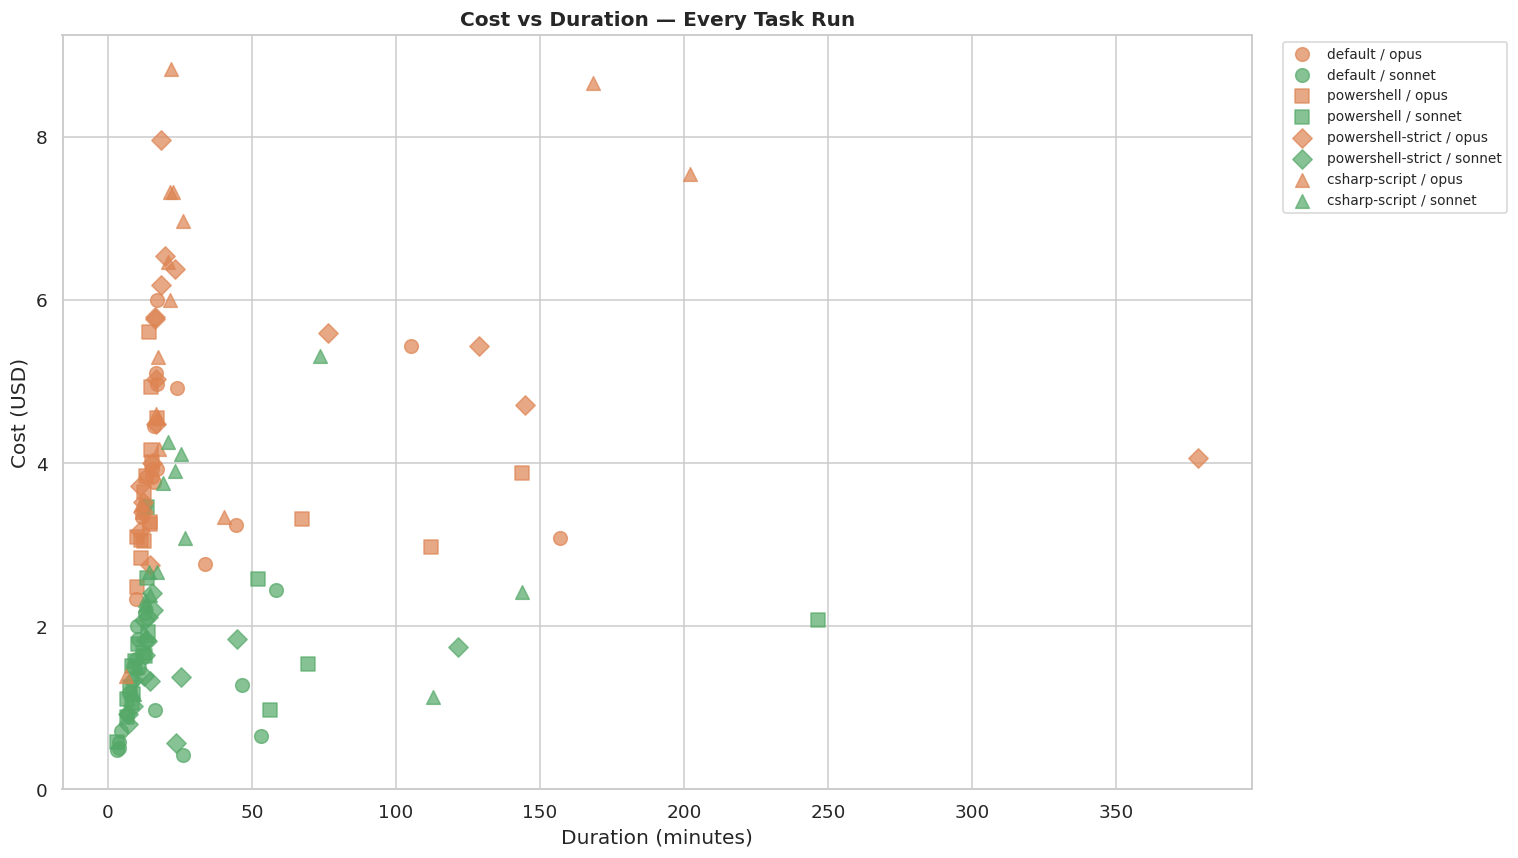

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
df_scatter = df_valid.copy()

markers = {"default": "o", "powershell": "s", "powershell-strict": "D", "csharp-script": "^"}
model_colors = {"opus": "#DD8452", "sonnet": "#55A868"}

for mode in mode_order:
    for model in model_order:
        sub = df_scatter[(df_scatter["mode"] == mode) & (df_scatter["model"] == model)]
        ax.scatter(sub["duration_min"], sub["cost_usd"], 
                   marker=markers[mode], color=model_colors[model], s=80, alpha=0.7,
                   label=f"{mode} / {model}")

ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost vs Duration — Every Task Run", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Failed / Stalled Runs

Runs with 0 cost or 0 turns likely stalled (e.g., tool install timeout, permission loop).

In [12]:
stalled = df[(df["cost_usd"] == 0) | (df["turns"] == 0)]
print(f"Stalled/failed runs: {len(stalled)} of {len(df)} ({len(stalled)/len(df)*100:.1f}%)\n")

if len(stalled) > 0:
    print(stalled[["task_id", "mode", "model", "duration_min", "cost_usd", "turns", "errors"]].to_string(index=False))
    
    print(f"\nStalled runs by mode:")
    print(stalled.groupby("mode").size().reindex(mode_order, fill_value=0).to_string())
    print(f"\nStalled runs by model:")
    print(stalled.groupby("model").size().to_string())

Stalled/failed runs: 5 of 144 (3.5%)

                        task_id              mode  model  duration_min  cost_usd  turns  errors
        01-csv-report-generator     csharp-script   opus    271.178167       0.0      0       0
             04-rest-api-client        powershell   opus    257.498000       0.0      0       0
        06-config-file-migrator     csharp-script   opus     54.235000       0.0      0       0
        08-database-seed-script     csharp-script sonnet     28.113967       0.0      0       0
16-environment-matrix-generator powershell-strict sonnet     30.000400       0.0      0       0

Stalled runs by mode:
mode
default              0
powershell           1
powershell-strict    1
csharp-script        3

Stalled runs by model:
model
opus      3
sonnet    2


## 12. Summary Table — All Metrics by Mode and Model

In [13]:
summary_table = df.groupby(["mode", "model"]).agg(
    tasks=("task_id", "count"),
    avg_cost=("cost_usd", "mean"),
    total_cost=("cost_usd", "sum"),
    avg_duration_min=("duration_min", "mean"),
    avg_lines=("lines", "mean"),
    avg_errors=("errors", "mean"),
    avg_turns=("turns", "mean"),
).round(2)

summary_table = summary_table.reindex(
    pd.MultiIndex.from_product([mode_order, model_order], names=["mode", "model"])
)

# Format for display
display_table = summary_table.copy()
display_table["avg_cost"] = display_table["avg_cost"].map("${:.2f}".format)
display_table["total_cost"] = display_table["total_cost"].map("${:.2f}".format)
display_table["avg_duration_min"] = display_table["avg_duration_min"].map("{:.1f} min".format)
display_table["avg_lines"] = display_table["avg_lines"].map("{:.0f}".format)
display_table["avg_errors"] = display_table["avg_errors"].map("{:.0f}".format)
display_table["avg_turns"] = display_table["avg_turns"].map("{:.0f}".format)

display_table.columns = ["Tasks", "Avg Cost", "Total Cost", "Avg Duration", "Avg Lines", "Avg Errors", "Avg Turns"]
display_table

Tasks Avg Cost Total Cost Avg Duration Avg Lines  \
mode              model                                                      
default           opus       18    $3.99     $71.84     30.9 min       745   
                  sonnet     18    $1.23     $22.08     16.7 min       728   
powershell        opus       18    $3.44     $61.98     42.7 min       756   
                  sonnet     18    $1.63     $29.38     31.1 min       634   
powershell-strict opus       18    $4.92     $88.48     52.8 min       883   
                  sonnet     18    $1.47     $26.42     22.3 min       772   
csharp-script     opus       18    $4.97     $89.38     53.8 min      9065   
                  sonnet     18    $2.62     $47.12     32.9 min      1202   

                         Avg Errors Avg Turns  
mode              model                        
default           opus          149       148  
                  sonnet         36        51  
powershell        opus           96       106  
                  sonnet         47        63  
powershell-strict opus          134       145  
                  sonnet         31        46  
csharp-script     opus          137       145  
                  sonnet         57        81

## 13. Detailed Per-Task Metrics

Load the individual metrics.json files for deeper analysis (tokens, compactions, tool installs).

In [14]:
# Load all individual metrics files for richer data
metrics_files = sorted(Path("results/2026-04-02_163146/tasks").glob("*/*/metrics.json"))
records = []
for mf in metrics_files:
    with open(mf) as f:
        m = json.load(f)
    records.append({
        "task_id": m["task_id"],
        "mode": m["language_mode"],
        "model": m["model_short"],
        "language": m.get("language_chosen", ""),
        "duration_s": m["timing"]["grand_total_duration_ms"] / 1000,
        "api_duration_s": m["timing"]["total_api_duration_ms"] / 1000,
        "exec_duration_s": m["timing"]["total_execution_duration_ms"] / 1000,
        "turns": m["timing"]["num_turns"],
        "input_tokens": m["tokens"]["input_tokens"],
        "output_tokens": m["tokens"]["output_tokens"],
        "cache_read_tokens": m["tokens"]["cache_read_tokens"],
        "cache_creation_tokens": m["tokens"]["cache_creation_tokens"],
        "total_context": m["tokens"]["total_context_consumed"],
        "compactions": m["tokens"]["compaction_count"],
        "cost_usd": m["cost"]["total_cost_usd"],
        "lines": m["code_metrics"]["total_lines"],
        "file_count": m["code_metrics"]["file_count"],
        "errors": m["quality"]["error_count"],
        "tool_install_s": m["tool_install"]["tool_install_duration_ms"] / 1000,
        "tools_installed": len(m["tool_install"]["tools_installed"]),
    })

df_detail = pd.DataFrame(records)
df_detail["duration_min"] = df_detail["duration_s"] / 60
df_detail["pct_api"] = df_detail["api_duration_s"] / df_detail["duration_s"] * 100
print(f"Loaded detailed metrics for {len(df_detail)} runs")
df_detail[["task_id", "mode", "model", "turns", "output_tokens", "compactions", "tool_install_s"]].head(10)

Loaded detailed metrics for 144 runs


,task_id,mode,model,turns,output_tokens,compactions,tool_install_s
0,01-csv-report-generator,csharp-script,opus,0,0,0,0.0
1,01-csv-report-generator,csharp-script,sonnet,48,28480,0,0.0
2,01-csv-report-generator,default,opus,222,27166,0,0.0
3,01-csv-report-generator,default,sonnet,37,13841,0,0.0
4,01-csv-report-generator,powershell,opus,97,27830,0,0.0
5,01-csv-report-generator,powershell,sonnet,52,21739,0,0.0
6,01-csv-report-generator,powershell-strict,opus,168,38292,0,0.0
7,01-csv-report-generator,powershell-strict,sonnet,74,35854,0,0.0
8,02-log-file-analyzer,csharp-script,opus,221,59455,0,0.0
9,02-log-file-analyzer,csharp-script,sonnet,131,77592,0,0.0


## 14. Token Usage — Output Tokens and Context Window Consumption

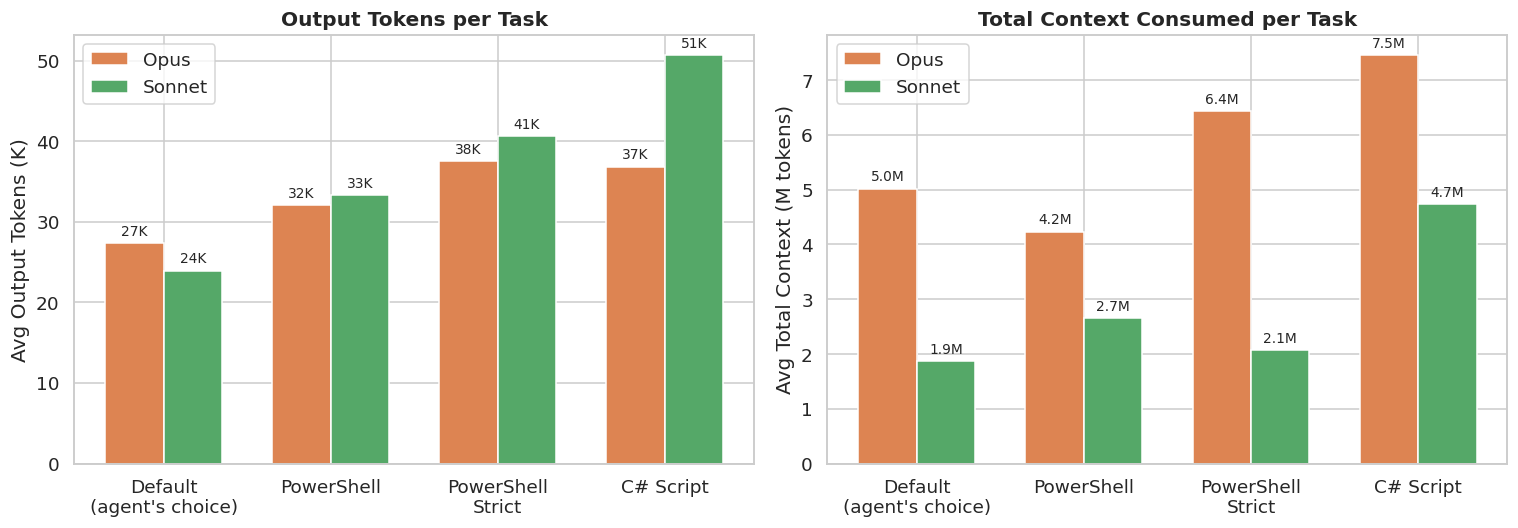

In [15]:
df_d = df_detail[df_detail["cost_usd"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Output tokens
ax = axes[0]
pivot_out = df_d.pivot_table(index="mode", columns="model", values="output_tokens", aggfunc="mean").reindex(mode_order)[model_order]
pivot_out_k = pivot_out / 1000
x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_out_k["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_out_k["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0fK", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.0fK", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Output Tokens (K)")
ax.set_title("Output Tokens per Task", fontweight="bold")
ax.legend()

# Total context consumed
ax = axes[1]
pivot_ctx = df_d.pivot_table(index="mode", columns="model", values="total_context", aggfunc="mean").reindex(mode_order)[model_order]
pivot_ctx_m = pivot_ctx / 1_000_000
x = np.arange(len(mode_order))
bars1 = ax.bar(x - w/2, pivot_ctx_m["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_ctx_m["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1fM", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1fM", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Total Context (M tokens)")
ax.set_title("Total Context Consumed per Task", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

## 15. Context Compactions and Tool Install Overhead

Compactions indicate the agent hit context limits. Tool install time is overhead before actual coding begins.

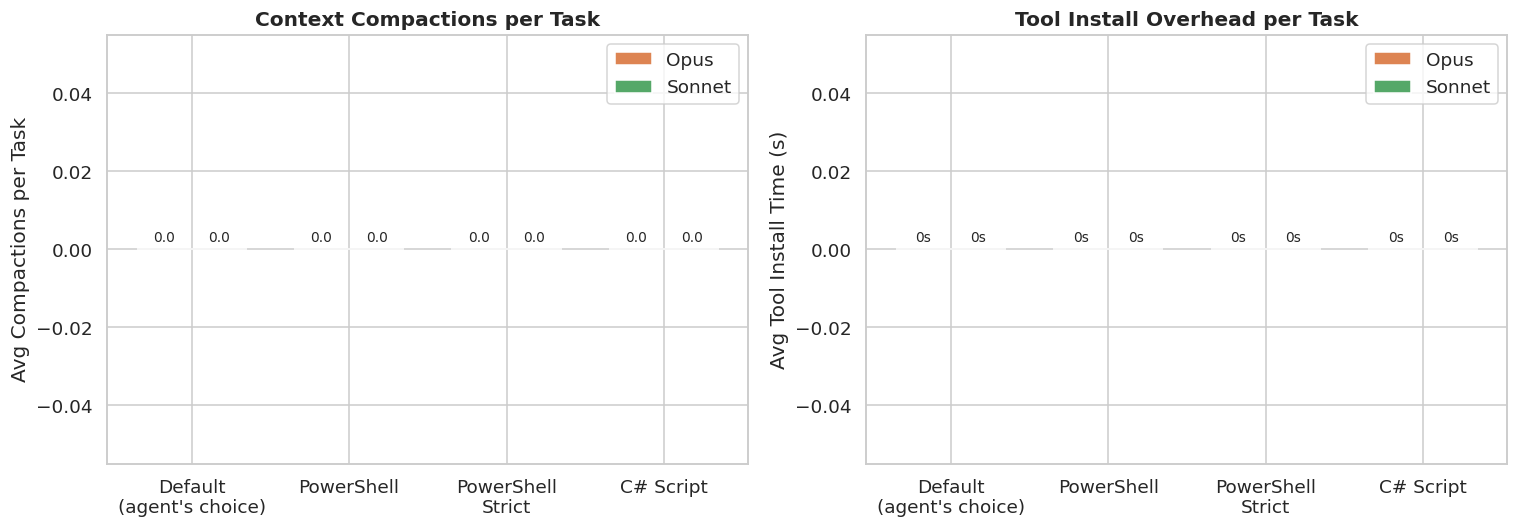

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compactions
ax = axes[0]
pivot_comp = df_d.pivot_table(index="mode", columns="model", values="compactions", aggfunc="mean").reindex(mode_order)[model_order]
x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_comp["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_comp["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Compactions per Task")
ax.set_title("Context Compactions per Task", fontweight="bold")
ax.legend()

# Tool install overhead
ax = axes[1]
pivot_ti = df_d.pivot_table(index="mode", columns="model", values="tool_install_s", aggfunc="mean").reindex(mode_order)[model_order]
bars1 = ax.bar(x - w/2, pivot_ti["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_ti["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0fs", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.0fs", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Tool Install Time (s)")
ax.set_title("Tool Install Overhead per Task", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

---

# Deep Dive: Why Do Modes Differ?

The sections above show *what* differs. The sections below investigate *why*.

## 16. Duration Decomposition — Where Does the Time Go?

Duration = API thinking time + local execution time + overhead. Let's see how modes split their time budget.

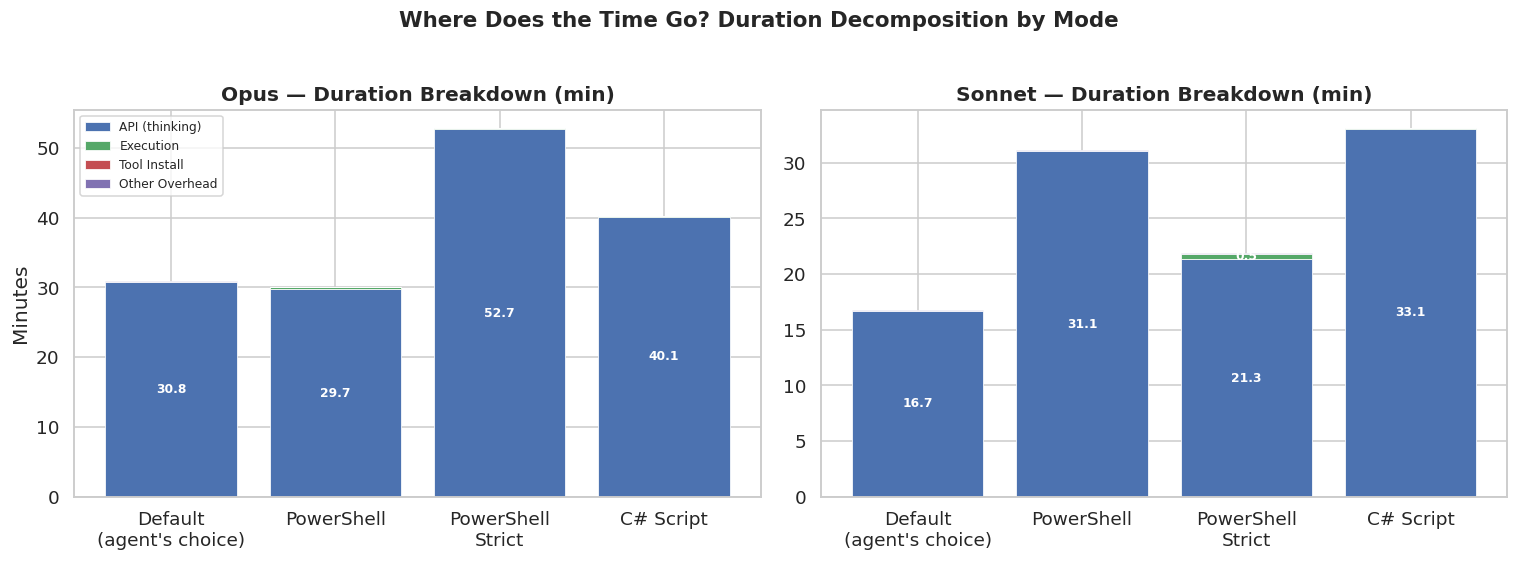


Duration breakdown (% of total wall-clock time):

  OPUS:
    default             : API=100%  Exec=0%  ToolInstall=0%  Other=0%
    powershell          : API=99%  Exec=1%  ToolInstall=0%  Other=0%
    powershell-strict   : API=100%  Exec=0%  ToolInstall=0%  Other=0%
    csharp-script       : API=100%  Exec=0%  ToolInstall=0%  Other=0%

  SONNET:
    default             : API=100%  Exec=0%  ToolInstall=0%  Other=0%
    powershell          : API=100%  Exec=0%  ToolInstall=0%  Other=0%
    powershell-strict   : API=98%  Exec=2%  ToolInstall=0%  Other=0%
    csharp-script       : API=100%  Exec=0%  ToolInstall=0%  Other=0%


In [17]:
# Decompose duration into API time, execution time, and other overhead
df_d["overhead_s"] = df_d["duration_s"] - df_d["api_duration_s"] - df_d["exec_duration_s"] - df_d["tool_install_s"]
df_d["overhead_s"] = df_d["overhead_s"].clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, model in enumerate(model_order):
    ax = axes[i]
    sub = df_d[df_d["model"] == model]
    agg = sub.groupby("mode")[["api_duration_s", "exec_duration_s", "tool_install_s", "overhead_s"]].mean().reindex(mode_order) / 60
    
    colors_stack = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    labels_stack = ["API (thinking)", "Execution", "Tool Install", "Other Overhead"]
    bottom = np.zeros(len(mode_order))
    
    for j, col in enumerate(agg.columns):
        bars = ax.bar([mode_labels[m] for m in mode_order], agg[col], bottom=bottom,
                      color=colors_stack[j], label=labels_stack[j], edgecolor="white", linewidth=0.5)
        # Label segments > 0.5 min
        for k, v in enumerate(agg[col]):
            if v > 0.5:
                ax.text(k, bottom[k] + v/2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        bottom += agg[col].values
    
    ax.set_title(f"{model.title()} — Duration Breakdown (min)", fontweight="bold")
    ax.set_ylabel("Minutes" if i == 0 else "")
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Where Does the Time Go? Duration Decomposition by Mode", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print the % breakdown
print("\nDuration breakdown (% of total wall-clock time):")
for model in model_order:
    print(f"\n  {model.upper()}:")
    sub = df_d[df_d["model"] == model]
    for mode in mode_order:
        ms = sub[sub["mode"] == mode]
        total = ms["duration_s"].mean()
        if total > 0:
            api_pct = ms["api_duration_s"].mean() / total * 100
            exec_pct = ms["exec_duration_s"].mean() / total * 100
            ti_pct = ms["tool_install_s"].mean() / total * 100
            print(f"    {mode:20s}: API={api_pct:.0f}%  Exec={exec_pct:.0f}%  ToolInstall={ti_pct:.0f}%  Other={100-api_pct-exec_pct-ti_pct:.0f}%")

## 17. Error Analysis — What Causes Errors and How Do They Cascade?

Errors often cause retry loops that burn tokens and time. Let's see which error types dominate and whether more errors predict higher cost.

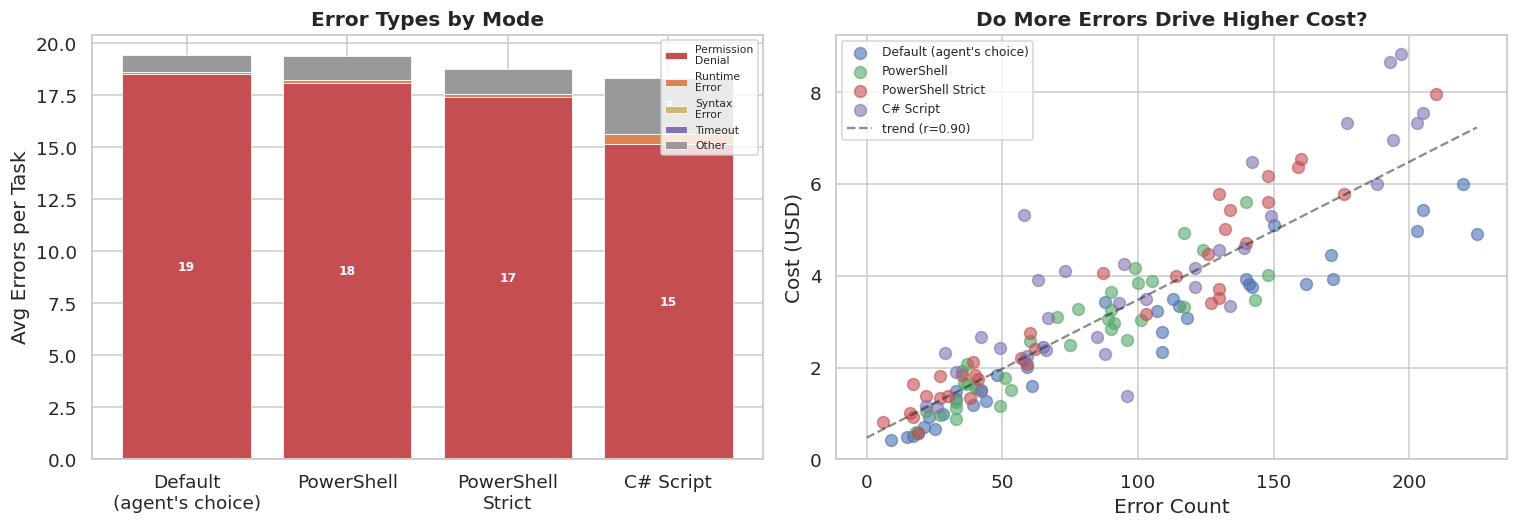


Correlation between errors and key metrics (non-stalled runs):
  errors vs cost_usd            : r = +0.900
  errors vs duration_min        : r = +0.122
  errors vs turns               : r = +0.950
  errors vs output_tokens       : r = +0.097


In [18]:
# Classify errors from the detailed metrics files
error_records = []
for mf in sorted(Path("results/2026-04-02_163146/tasks").glob("*/*/metrics.json")):
    with open(mf) as f:
        m = json.load(f)
    details = m["quality"].get("error_details", [])
    cats = {"permission_denial": 0, "runtime_error": 0, "syntax_error": 0, "timeout": 0, "other": 0}
    for err in details:
        err_lower = err.lower()
        if "approval" in err_lower or "permission" in err_lower or "requires approval" in err_lower:
            cats["permission_denial"] += 1
        elif "timeout" in err_lower or "timed out" in err_lower:
            cats["timeout"] += 1
        elif "syntax" in err_lower or "parse" in err_lower:
            cats["syntax_error"] += 1
        elif any(kw in err_lower for kw in ["error", "exception", "fail", "traceback", "not found", "cannot"]):
            cats["runtime_error"] += 1
        else:
            cats["other"] += 1
    error_records.append({
        "task_id": m["task_id"], "mode": m["language_mode"], "model": m["model_short"],
        "total_errors": len(details), **cats
    })

df_err = pd.DataFrame(error_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error type breakdown by mode
ax = axes[0]
err_cats = ["permission_denial", "runtime_error", "syntax_error", "timeout", "other"]
err_labels = ["Permission\nDenial", "Runtime\nError", "Syntax\nError", "Timeout", "Other"]
err_colors = ["#C44E52", "#DD8452", "#CCB974", "#8172B2", "#999999"]

agg_err = df_err.groupby("mode")[err_cats].mean().reindex(mode_order)
bottom = np.zeros(len(mode_order))
for j, cat in enumerate(err_cats):
    bars = ax.bar([mode_labels[m] for m in mode_order], agg_err[cat], bottom=bottom,
                  color=err_colors[j], label=err_labels[j], edgecolor="white", linewidth=0.5)
    for k, v in enumerate(agg_err[cat]):
        if v > 2:
            ax.text(k, bottom[k] + v/2, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += agg_err[cat].values
ax.set_ylabel("Avg Errors per Task")
ax.set_title("Error Types by Mode", fontweight="bold")
ax.legend(fontsize=7, loc="upper right")

# Right: scatter — errors vs cost (does more errors = more $?)
ax = axes[1]
for mode in mode_order:
    sub = df_d[df_d["mode"] == mode]
    ax.scatter(sub["errors"], sub["cost_usd"], marker="o", alpha=0.6, s=60, 
               color=palette[mode], label=mode_labels[mode].replace("\n", " "))
# Add trend line across all data
from numpy.polynomial.polynomial import polyfit
mask = df_d["errors"] > 0
if mask.sum() > 5:
    b, m_slope = polyfit(df_d.loc[mask, "errors"], df_d.loc[mask, "cost_usd"], 1)
    x_line = np.linspace(0, df_d["errors"].max(), 50)
    ax.plot(x_line, b + m_slope * x_line, "k--", alpha=0.5, label=f"trend (r={df_d.loc[mask, 'errors'].corr(df_d.loc[mask, 'cost_usd']):.2f})")
ax.set_xlabel("Error Count")
ax.set_ylabel("Cost (USD)")
ax.set_title("Do More Errors Drive Higher Cost?", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print correlation stats
print("\nCorrelation between errors and key metrics (non-stalled runs):")
for col in ["cost_usd", "duration_min", "turns", "output_tokens"]:
    r = df_d["errors"].corr(df_d[col])
    print(f"  errors vs {col:20s}: r = {r:+.3f}")

## 18. Context Consumption — Why Do Some Modes Burn More Tokens?

Context window usage drives cost. Let's examine how input vs output vs cache tokens differ, and how compactions relate to the conversation length.

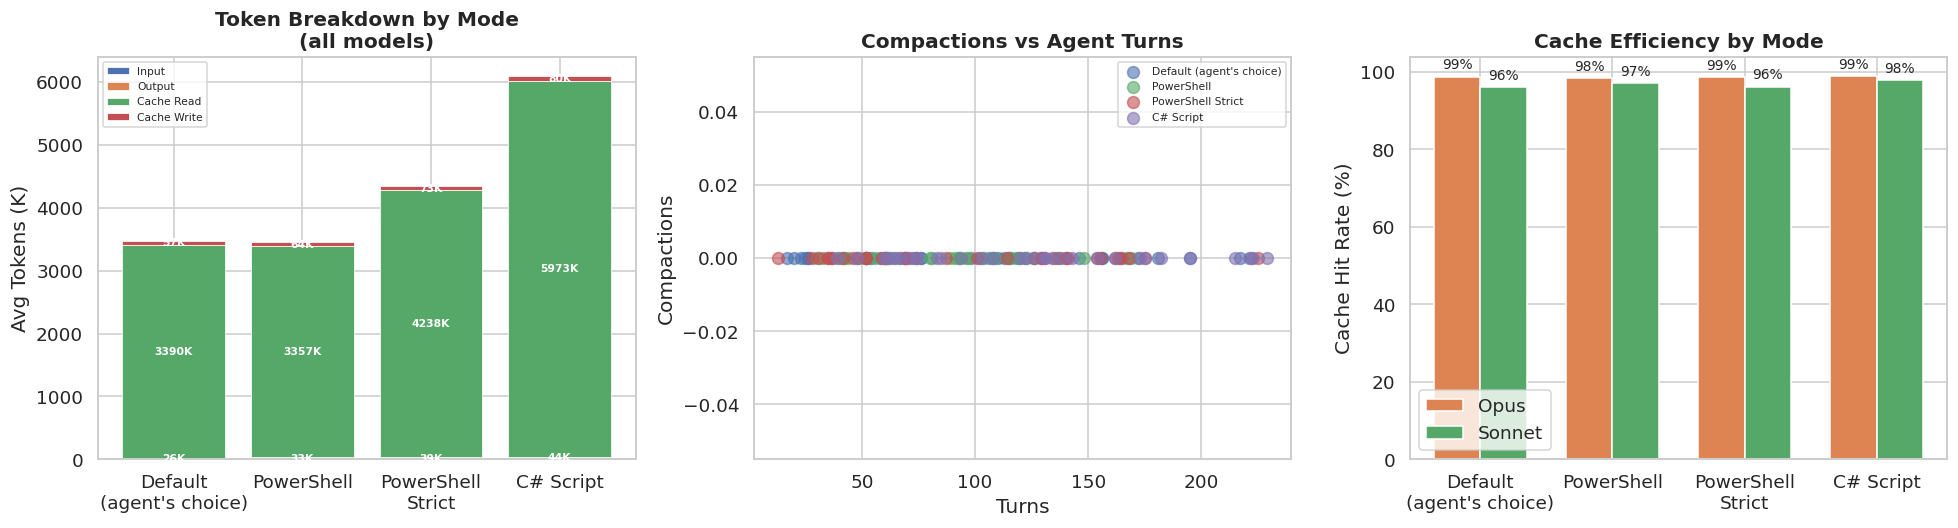


Avg tokens per turn (output tokens / turns):
  OPUS: default=190  powershell=292  powershell-strict=262  csharp-script=225
  SONNET: default=492  powershell=580  powershell-strict=955  csharp-script=624


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Token breakdown: input vs output vs cache-read vs cache-write
ax = axes[0]
token_cols = ["input_tokens", "output_tokens", "cache_read_tokens", "cache_creation_tokens"]
token_labels = ["Input", "Output", "Cache Read", "Cache Write"]
token_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

agg_tok = df_d.groupby("mode")[token_cols].mean().reindex(mode_order) / 1000
bottom = np.zeros(len(mode_order))
for j, col in enumerate(token_cols):
    ax.bar([mode_labels[m] for m in mode_order], agg_tok[col], bottom=bottom,
           color=token_colors[j], label=token_labels[j], edgecolor="white", linewidth=0.5)
    for k, v in enumerate(agg_tok[col]):
        if v > 20:
            ax.text(k, bottom[k] + v/2, f"{v:.0f}K", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    bottom += agg_tok[col].values
ax.set_ylabel("Avg Tokens (K)")
ax.set_title("Token Breakdown by Mode\n(all models)", fontweight="bold")
ax.legend(fontsize=7)

# 2) Compactions vs turns — do more turns cause compactions?
ax = axes[1]
for mode in mode_order:
    sub = df_d[df_d["mode"] == mode]
    ax.scatter(sub["turns"], sub["compactions"], alpha=0.6, s=60, color=palette[mode],
               label=mode_labels[mode].replace("\n", " "))
ax.set_xlabel("Turns")
ax.set_ylabel("Compactions")
ax.set_title("Compactions vs Agent Turns", fontweight="bold")
ax.legend(fontsize=7)

# 3) Cache hit rate by mode — how efficiently does each mode reuse context?
ax = axes[2]
df_d["cache_hit_rate"] = df_d["cache_read_tokens"] / (df_d["cache_read_tokens"] + df_d["cache_creation_tokens"] + df_d["input_tokens"] + 1) * 100
pivot_cache = df_d.pivot_table(index="mode", columns="model", values="cache_hit_rate", aggfunc="mean").reindex(mode_order)[model_order]
x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_cache["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_cache["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0f%%", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.0f%%", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Cache Hit Rate (%)")
ax.set_title("Cache Efficiency by Mode", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

# Summary stats
print("\nAvg tokens per turn (output tokens / turns):")
df_d["tokens_per_turn"] = df_d["output_tokens"] / df_d["turns"].clip(lower=1)
for model in model_order:
    sub = df_d[df_d["model"] == model]
    tpt = sub.groupby("mode")["tokens_per_turn"].mean().reindex(mode_order)
    print(f"  {model.upper()}: " + "  ".join(f"{m}={tpt[m]:.0f}" for m in mode_order))

## 19. Task Difficulty Spectrum — Which Tasks Punish Non-Default Modes?

Some tasks are "mode-neutral" (similar cost regardless of mode), while others have massive mode-dependent swings. Let's identify the tasks where mode choice matters most, and where it doesn't.

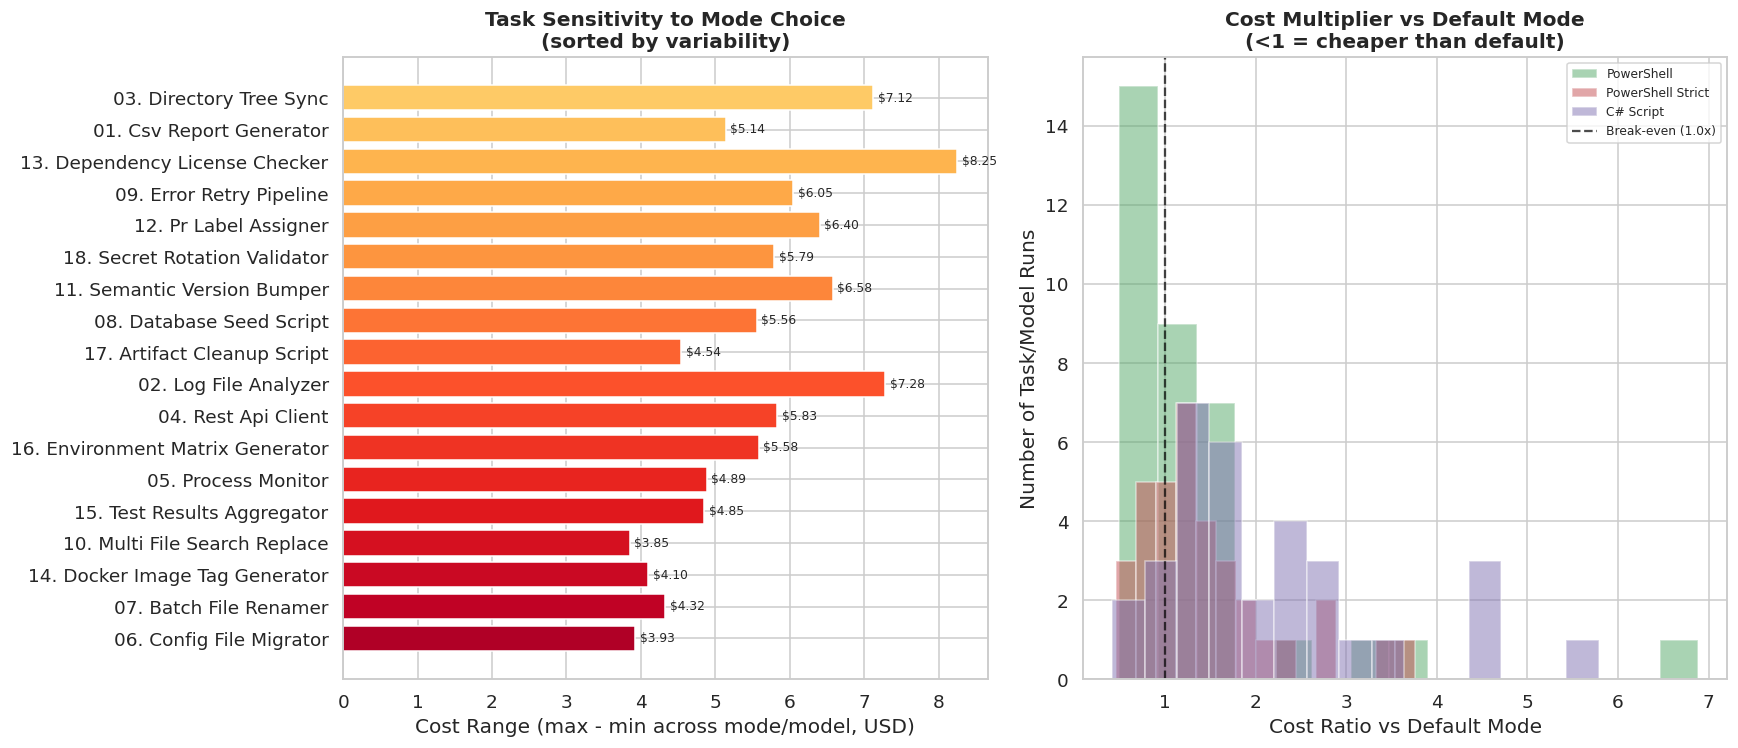


Cost ratio vs default mode (1.0 = same cost as default):
                   Mean Ratio  Median Ratio
mode                                       
csharp-script            2.11          1.73
powershell               1.38          1.05
powershell-strict        1.45          1.24

Tasks where PowerShell is CHEAPER than default:
  01-csv-report-generator (opus): 0.62x
  02-log-file-analyzer (opus): 0.71x
  05-process-monitor (sonnet): 0.69x
  06-config-file-migrator (opus): 0.71x
  09-error-retry-pipeline (opus): 0.83x
  09-error-retry-pipeline (sonnet): 0.70x
  12-pr-label-assigner (opus): 0.66x
  13-dependency-license-checker (opus): 0.69x
  13-dependency-license-checker (sonnet): 0.49x
  14-docker-image-tag-generator (opus): 0.80x
  15-test-results-aggregator (opus): 0.62x
  15-test-results-aggregator (sonnet): 0.78x
  16-environment-matrix-generator (sonnet): 0.67x
  17-artifact-cleanup-script (opus): 0.81x

Tasks where C# is MUCH MORE EXPENSIVE than default (>2x):
  02-log-file-analyz

In [20]:
# Compute the "mode sensitivity" of each task: coefficient of variation of cost across modes
task_var = df_d.groupby("task_id")["cost_usd"].agg(["mean", "std", "min", "max"])
task_var["cv"] = task_var["std"] / task_var["mean"]  # coefficient of variation
task_var["range"] = task_var["max"] - task_var["min"]
task_var["range_pct"] = task_var["range"] / task_var["mean"] * 100
task_var = task_var.sort_values("cv", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: range of cost per task (max - min across all mode/model combos)
ax = axes[0]
task_labels = [f"{tid[:2]}. {tid[3:].replace('-', ' ').title()}" for tid in task_var.index]
colors_range = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(task_var)))
bars = ax.barh(task_labels, task_var["range"], color=colors_range, edgecolor="white")
ax.bar_label(bars, labels=[f"${v:.2f}" for v in task_var["range"]], padding=3, fontsize=8)
ax.set_xlabel("Cost Range (max - min across mode/model, USD)")
ax.set_title("Task Sensitivity to Mode Choice\n(sorted by variability)", fontweight="bold")
ax.invert_yaxis()

# Right: for each task, show cost per mode (default vs powershell vs csharp-script)
ax = axes[1]
# Compute ratio: non-default mode cost / default mode cost
ratios = []
for task_id in df_d["task_id"].unique():
    for model in model_order:
        tsub = df_d[(df_d["task_id"] == task_id) & (df_d["model"] == model)]
        default_cost = tsub[tsub["mode"] == "default"]["cost_usd"].values
        if len(default_cost) == 0 or default_cost[0] == 0:
            continue
        for mode in ["powershell", "powershell-strict", "csharp-script"]:
            mode_cost = tsub[tsub["mode"] == mode]["cost_usd"].values
            if len(mode_cost) > 0 and mode_cost[0] > 0:
                ratios.append({"task_id": task_id, "model": model, "mode": mode, 
                               "cost_ratio": mode_cost[0] / default_cost[0]})

df_ratios = pd.DataFrame(ratios)
if len(df_ratios) > 0:
    pivot_ratio = df_ratios.pivot_table(index="mode", values="cost_ratio", aggfunc=["mean", "median"]).round(2)
    pivot_ratio.columns = ["Mean Ratio", "Median Ratio"]
    
    for mode in ["powershell", "powershell-strict", "csharp-script"]:
        sub = df_ratios[df_ratios["mode"] == mode]
        ax.hist(sub["cost_ratio"], bins=15, alpha=0.5, label=mode_labels[mode].replace("\n", " "),
                color=palette[mode], edgecolor="white")
    ax.axvline(1.0, color="black", linestyle="--", alpha=0.7, label="Break-even (1.0x)")
    ax.set_xlabel("Cost Ratio vs Default Mode")
    ax.set_ylabel("Number of Task/Model Runs")
    ax.set_title("Cost Multiplier vs Default Mode\n(<1 = cheaper than default)", fontweight="bold")
    ax.legend(fontsize=8)
    
plt.tight_layout()
plt.show()

# Print the ratio summary
if len(df_ratios) > 0:
    print("\nCost ratio vs default mode (1.0 = same cost as default):")
    print(pivot_ratio.to_string())
    
    print("\nTasks where PowerShell is CHEAPER than default:")
    cheaper = df_ratios[(df_ratios["mode"] == "powershell") & (df_ratios["cost_ratio"] < 0.9)]
    for _, r in cheaper.iterrows():
        print(f"  {r['task_id']} ({r['model']}): {r['cost_ratio']:.2f}x")
    
    print("\nTasks where C# is MUCH MORE EXPENSIVE than default (>2x):")
    expensive = df_ratios[(df_ratios["mode"] == "csharp-script") & (df_ratios["cost_ratio"] > 2.0)]
    for _, r in expensive.iterrows():
        print(f"  {r['task_id']} ({r['model']}): {r['cost_ratio']:.2f}x")

## 20. Iteration Loops — Turns per Error and the Debugging Tax

When the agent encounters an error, how many extra turns does it spend recovering? This "debugging tax" explains a major portion of the cost and duration differences.

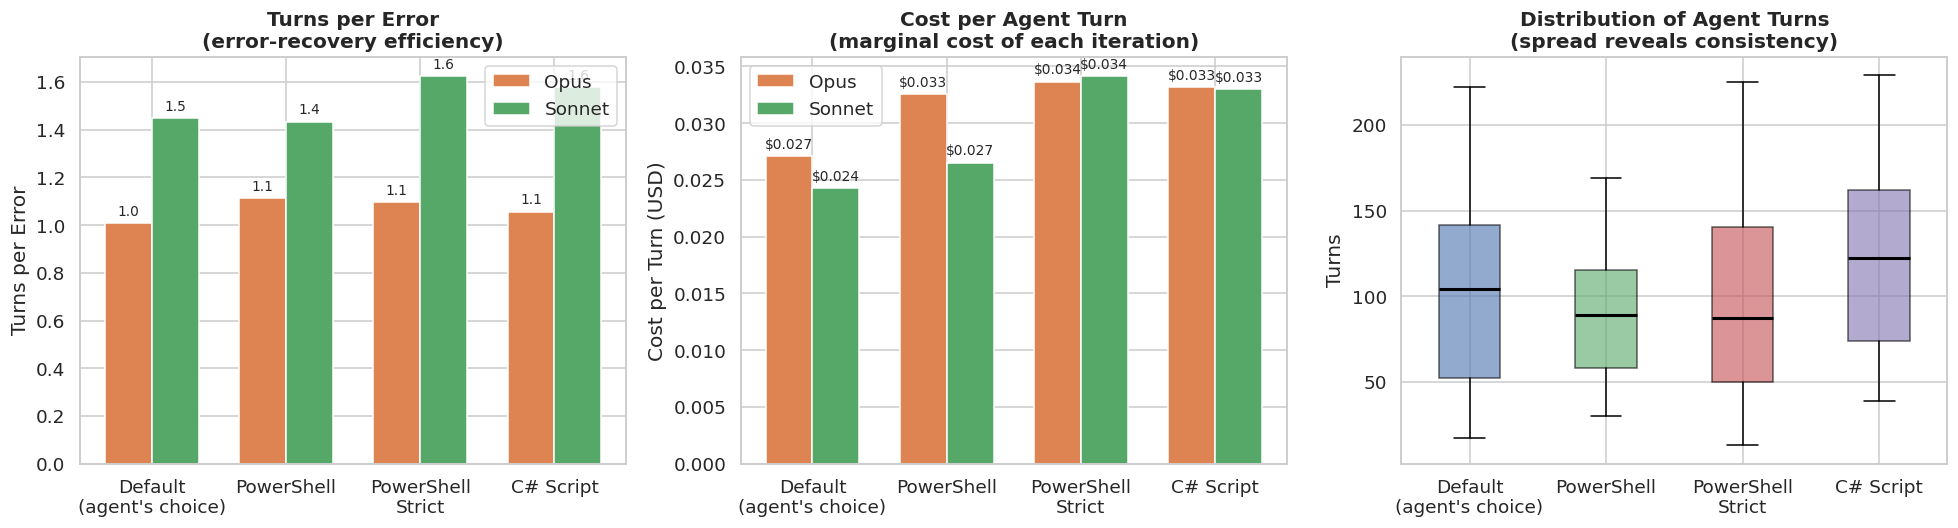


Debugging Tax Analysis (low-error vs high-error runs):
  Overall median error count: 87

  default (median errors = 76):
    Low-error runs  (≤76 errs): avg $1.23, 17 min, avg 36 errors  (n=18)
    High-error runs (>76 errs): avg $3.99, 31 min, avg 149 errors  (n=18)
    High-error tax:   +$2.76 cost (+225%), +14 min

  powershell (median errors = 75):
    Low-error runs  (≤75 errs): avg $1.61, 31 min, avg 42 errors  (n=18)
    High-error runs (>75 errs): avg $3.67, 30 min, avg 107 errors  (n=17)
    High-error tax:   +$2.07 cost (+129%), +-0 min

  powershell-strict (median errors = 62):
    Low-error runs  (≤62 errs): avg $1.62, 21 min, avg 34 errors  (n=18)
    High-error runs (>62 errs): avg $5.04, 55 min, avg 138 errors  (n=17)
    High-error tax:   +$3.42 cost (+211%), +34 min

  csharp-script (median errors = 95):
    Low-error runs  (≤95 errs): avg $2.75, 33 min, avg 58 errors  (n=17)
    High-error runs (>95 errs): avg $5.61, 41 min, avg 156 errors  (n=16)
    High-error tax:

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Turns per error: efficiency of error recovery
ax = axes[0]
df_err_runs = df_d[df_d["errors"] > 0].copy()
df_err_runs["turns_per_error"] = df_err_runs["turns"] / df_err_runs["errors"]
pivot_tpe = df_err_runs.pivot_table(index="mode", columns="model", values="turns_per_error", aggfunc="mean").reindex(mode_order)[model_order]
x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_tpe["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_tpe["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Turns per Error")
ax.set_title("Turns per Error\n(error-recovery efficiency)", fontweight="bold")
ax.legend()

# 2) Cost per turn by mode — how expensive is each "thinking step"?
ax = axes[1]
df_d["cost_per_turn"] = df_d["cost_usd"] / df_d["turns"].clip(lower=1)
pivot_cpt = df_d.pivot_table(index="mode", columns="model", values="cost_per_turn", aggfunc="mean").reindex(mode_order)[model_order]
bars1 = ax.bar(x - w/2, pivot_cpt["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_cpt["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="$%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="$%.3f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Cost per Turn (USD)")
ax.set_title("Cost per Agent Turn\n(marginal cost of each iteration)", fontweight="bold")
ax.legend()

# 3) Box plot of turns by mode to see dispersion
ax = axes[2]
data_box = [df_d[df_d["mode"] == m]["turns"].values for m in mode_order]
bp = ax.boxplot(data_box, tick_labels=[mode_labels[m] for m in mode_order], patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, mode in zip(bp["boxes"], mode_order):
    patch.set_facecolor(palette[mode])
    patch.set_alpha(0.6)
ax.set_ylabel("Turns")
ax.set_title("Distribution of Agent Turns\n(spread reveals consistency)", fontweight="bold")

plt.tight_layout()
plt.show()

# Debugging tax: compare low-error vs high-error runs (split at per-mode median)
# All runs have errors, so we compare below-median vs above-median error counts
print("\nDebugging Tax Analysis (low-error vs high-error runs):")
print("=" * 70)
median_errors = df_d["errors"].median()
print(f"  Overall median error count: {median_errors:.0f}\n")

for mode in mode_order:
    sub = df_d[df_d["mode"] == mode]
    mode_median = sub["errors"].median()
    low_err = sub[sub["errors"] <= mode_median]
    high_err = sub[sub["errors"] > mode_median]
    if len(low_err) > 0 and len(high_err) > 0:
        low_cost = low_err["cost_usd"].mean()
        high_cost = high_err["cost_usd"].mean()
        low_dur = low_err["duration_min"].mean()
        high_dur = high_err["duration_min"].mean()
        print(f"  {mode} (median errors = {mode_median:.0f}):")
        print(f"    Low-error runs  (\u2264{mode_median:.0f} errs): avg ${low_cost:.2f}, {low_dur:.0f} min, avg {low_err['errors'].mean():.0f} errors  (n={len(low_err)})")
        print(f"    High-error runs (>{mode_median:.0f} errs): avg ${high_cost:.2f}, {high_dur:.0f} min, avg {high_err['errors'].mean():.0f} errors  (n={len(high_err)})")
        if low_cost > 0:
            print(f"    High-error tax:   +${high_cost - low_cost:.2f} cost (+{(high_cost/low_cost - 1)*100:.0f}%), +{high_dur - low_dur:.0f} min\n")

## 21. Verbosity vs Efficiency — Lines of Code as a Cost Driver

C# is famously verbose. Does producing more lines of code inherently cost more, or does the agent compensate by writing more code per turn?

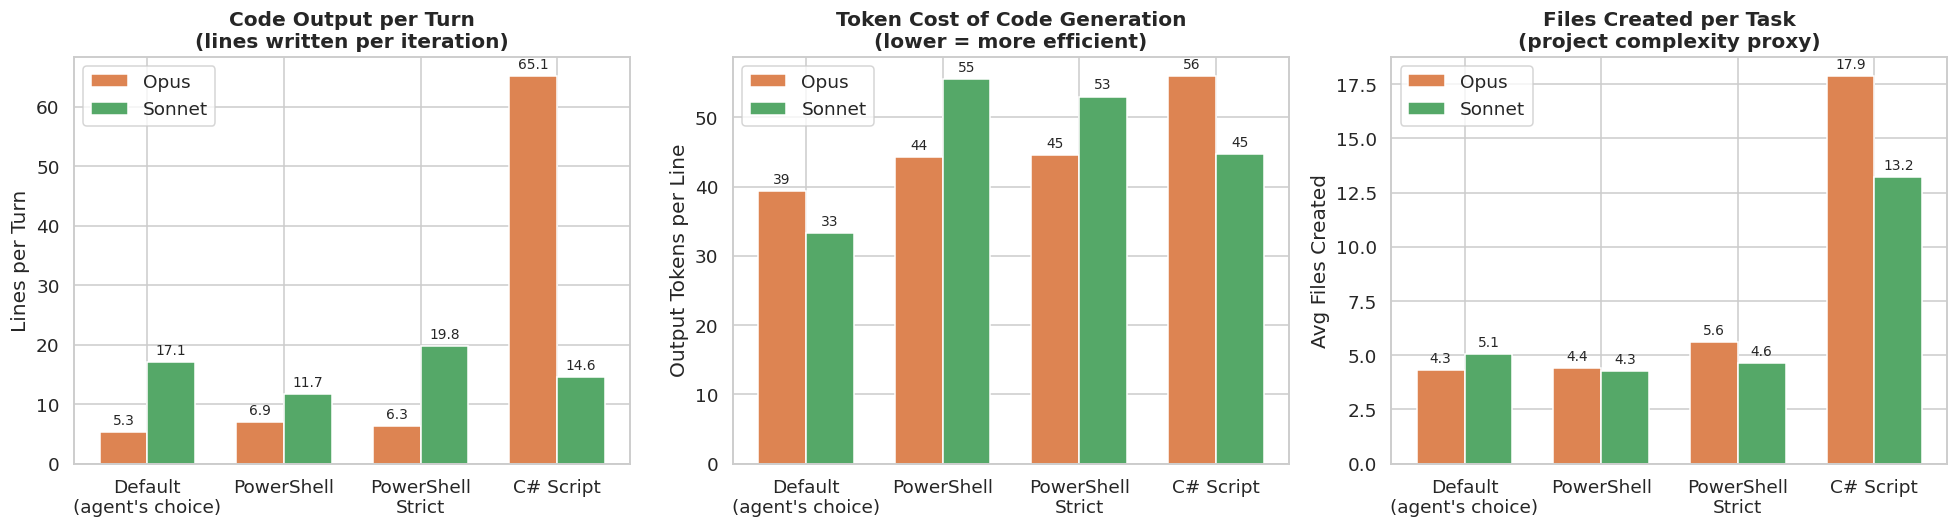


Verbosity comparison (lines of code for same task, averaged across tasks):

  OPUS:
    powershell vs default: 1.05x lines on average
    powershell-strict vs default: 1.21x lines on average
    csharp-script vs default: 23.88x lines on average

  SONNET:
    powershell vs default: 0.91x lines on average
    powershell-strict vs default: 1.19x lines on average
    csharp-script vs default: 1.67x lines on average


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Lines per turn — code output efficiency
ax = axes[0]
df_d["lines_per_turn"] = df_d["lines"] / df_d["turns"].clip(lower=1)
pivot_lpt = df_d.pivot_table(index="mode", columns="model", values="lines_per_turn", aggfunc="mean").reindex(mode_order)[model_order]
x = np.arange(len(mode_order))
w = 0.35
bars1 = ax.bar(x - w/2, pivot_lpt["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_lpt["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Lines per Turn")
ax.set_title("Code Output per Turn\n(lines written per iteration)", fontweight="bold")
ax.legend()

# 2) Output tokens per line of code — how many tokens does the agent spend to produce each line?
ax = axes[1]
df_d["tokens_per_line"] = df_d["output_tokens"] / df_d["lines"].clip(lower=1)
pivot_tpl = df_d.pivot_table(index="mode", columns="model", values="tokens_per_line", aggfunc="mean").reindex(mode_order)[model_order]
bars1 = ax.bar(x - w/2, pivot_tpl["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_tpl["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.0f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.0f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Output Tokens per Line")
ax.set_title("Token Cost of Code Generation\n(lower = more efficient)", fontweight="bold")
ax.legend()

# 3) Files created by mode
ax = axes[2]
pivot_fc = df_d.pivot_table(index="mode", columns="model", values="file_count", aggfunc="mean").reindex(mode_order)[model_order]
bars1 = ax.bar(x - w/2, pivot_fc["opus"], w, label="Opus", color="#DD8452")
bars2 = ax.bar(x + w/2, pivot_fc["sonnet"], w, label="Sonnet", color="#55A868")
ax.bar_label(bars1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Avg Files Created")
ax.set_title("Files Created per Task\n(project complexity proxy)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

# Verbosity ratio
print("\nVerbosity comparison (lines of code for same task, averaged across tasks):")
for model in model_order:
    sub = df_d[df_d["model"] == model]
    default_lines = sub[sub["mode"] == "default"].groupby("task_id")["lines"].mean()
    print(f"\n  {model.upper()}:")
    for mode in ["powershell", "powershell-strict", "csharp-script"]:
        mode_lines = sub[sub["mode"] == mode].groupby("task_id")["lines"].mean()
        common = default_lines.index.intersection(mode_lines.index)
        if len(common) > 0:
            ratio = (mode_lines[common] / default_lines[common].clip(lower=1)).mean()
            print(f"    {mode} vs default: {ratio:.2f}x lines on average")

## 22. Multi-Factor Correlation Matrix — What Actually Drives Cost?

A correlation heatmap across all numeric metrics to identify the strongest predictors of cost, duration, and error count.

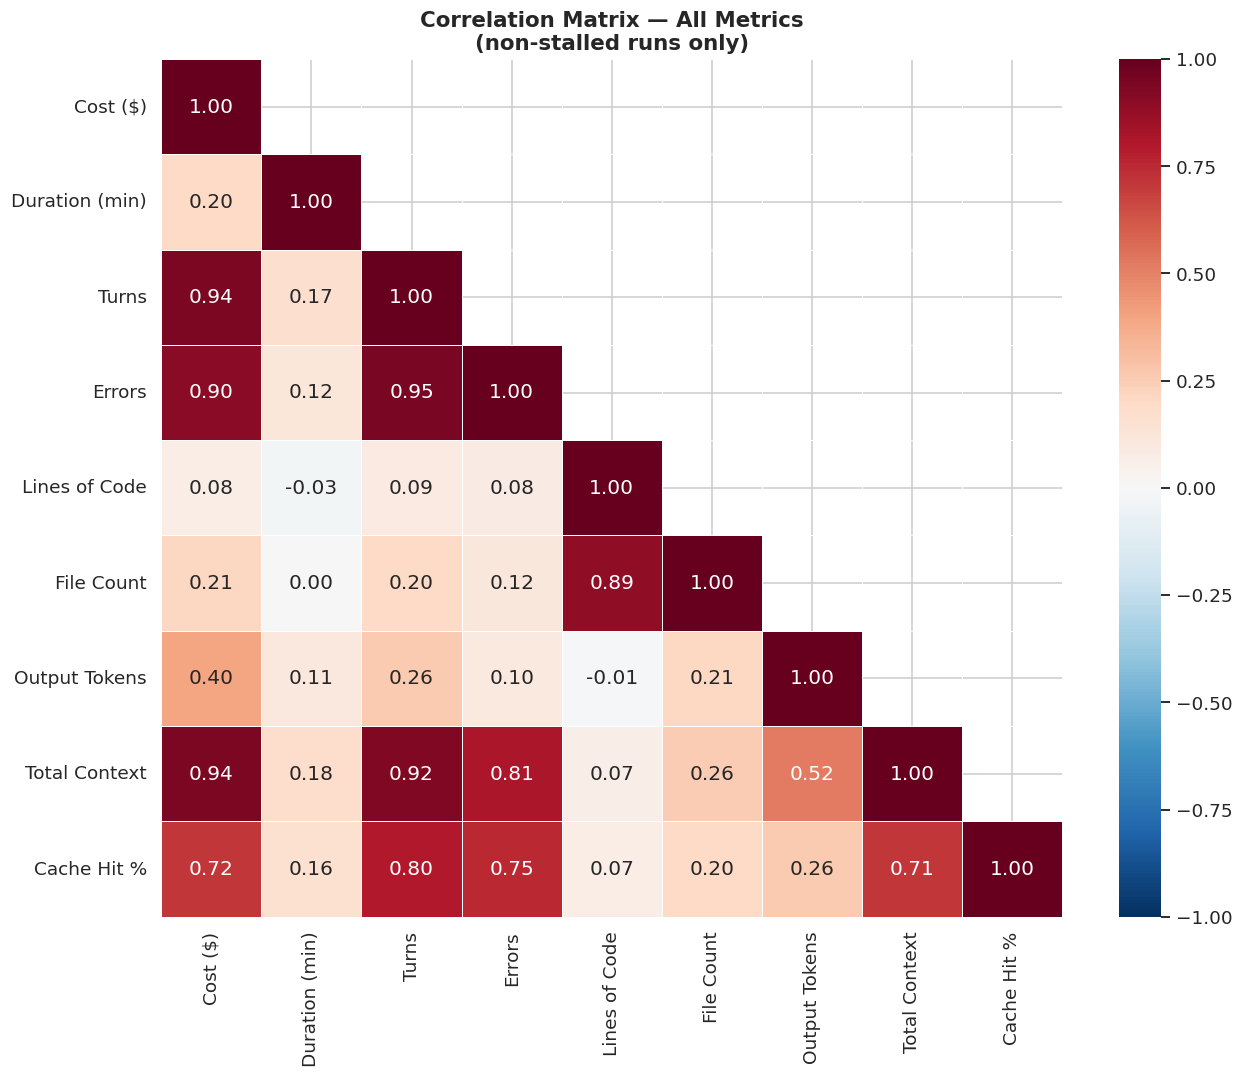


Top correlates of COST (absolute |r|):
  + total_context            : r = +0.944
  + turns                    : r = +0.938
  + errors                   : r = +0.900
  + cache_hit_rate           : r = +0.715
  + output_tokens            : r = +0.395
  + file_count               : r = +0.214
  + duration_min             : r = +0.201
  + lines                    : r = +0.078

Top correlates of ERRORS:
  + turns                    : r = +0.950
  + cost_usd                 : r = +0.900
  + total_context            : r = +0.813
  + cache_hit_rate           : r = +0.751
  + duration_min             : r = +0.122
  + file_count               : r = +0.115
  + output_tokens            : r = +0.097
  + lines                    : r = +0.081


In [23]:
# Exclude zero-variance columns (compactions and tool_install_s are all 0 in this benchmark)
corr_cols = ["cost_usd", "duration_min", "turns", "errors", "lines", "file_count",
             "output_tokens", "total_context", "cache_hit_rate"]
corr_labels = ["Cost ($)", "Duration (min)", "Turns", "Errors", "Lines of Code", "File Count",
               "Output Tokens", "Total Context", "Cache Hit %"]

corr_matrix = df_d[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=corr_labels, yticklabels=corr_labels, linewidths=0.5,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix — All Metrics\n(non-stalled runs only)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# Top drivers of cost
print("\nTop correlates of COST (absolute |r|):")
cost_corr = corr_matrix["cost_usd"].drop("cost_usd").abs().sort_values(ascending=False)
for col, r in cost_corr.items():
    direction = "+" if corr_matrix.loc["cost_usd", col] > 0 else "-"
    print(f"  {direction} {col:25s}: r = {corr_matrix.loc['cost_usd', col]:+.3f}")

print("\nTop correlates of ERRORS:")
err_corr = corr_matrix["errors"].drop("errors").abs().sort_values(ascending=False)
for col, r in err_corr.items():
    direction = "+" if corr_matrix.loc["errors", col] > 0 else "-"
    print(f"  {direction} {col:25s}: r = {corr_matrix.loc['errors', col]:+.3f}")

## 23. Opus vs Sonnet Head-to-Head — Same Task, Same Mode, Different Model

For each task/mode combination, which model is cheaper, faster, and produces more code? This controls for task difficulty.

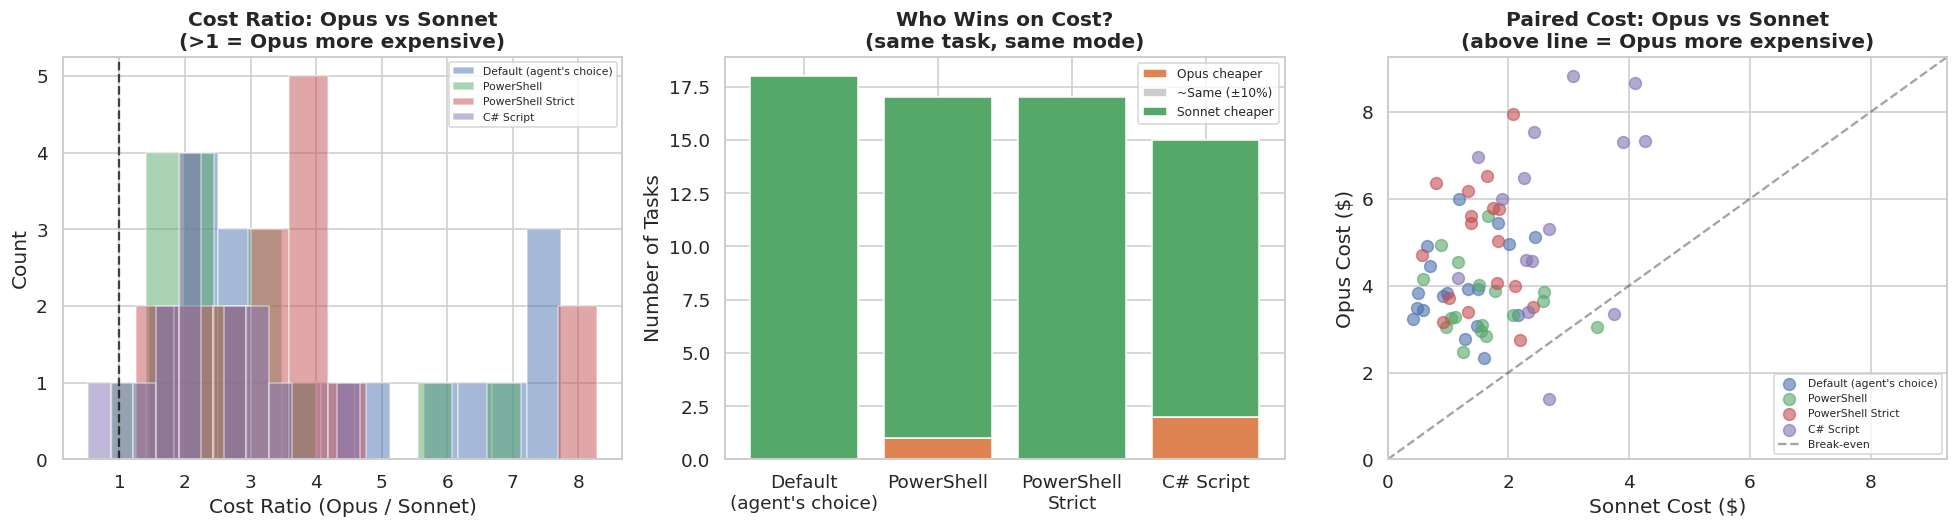


Head-to-head summary (67 paired runs):
  Median cost ratio (Opus/Sonnet): 2.87x
  Median duration ratio:           1.46x
  Median turns ratio:              2.27x
  Opus cheaper in:                 3 / 67 runs
  Sonnet cheaper in:               64 / 67 runs


In [24]:
# Head-to-head: pair each opus run with its sonnet counterpart (same task + mode)
h2h = []
for task_id in df_d["task_id"].unique():
    for mode in mode_order:
        opus = df_d[(df_d["task_id"] == task_id) & (df_d["mode"] == mode) & (df_d["model"] == "opus")]
        sonnet = df_d[(df_d["task_id"] == task_id) & (df_d["mode"] == mode) & (df_d["model"] == "sonnet")]
        if len(opus) == 1 and len(sonnet) == 1:
            o, s = opus.iloc[0], sonnet.iloc[0]
            h2h.append({
                "task_id": task_id, "mode": mode,
                "cost_ratio": o["cost_usd"] / max(s["cost_usd"], 0.01),
                "dur_ratio": o["duration_s"] / max(s["duration_s"], 1),
                "lines_ratio": o["lines"] / max(s["lines"], 1),
                "turns_ratio": o["turns"] / max(s["turns"], 1),
                "errors_diff": o["errors"] - s["errors"],
                "opus_cost": o["cost_usd"], "sonnet_cost": s["cost_usd"],
            })

df_h2h = pd.DataFrame(h2h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Distribution of cost ratio (opus / sonnet)
ax = axes[0]
for mode in mode_order:
    sub = df_h2h[df_h2h["mode"] == mode]
    ax.hist(sub["cost_ratio"], bins=12, alpha=0.5, color=palette[mode], 
            label=mode_labels[mode].replace("\n", " "), edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", alpha=0.7)
ax.set_xlabel("Cost Ratio (Opus / Sonnet)")
ax.set_ylabel("Count")
ax.set_title("Cost Ratio: Opus vs Sonnet\n(>1 = Opus more expensive)", fontweight="bold")
ax.legend(fontsize=7)

# 2) Opus wins by mode (cheaper AND faster)
ax = axes[1]
win_data = {"opus_cheaper": [], "sonnet_cheaper": [], "tie": []}
for mode in mode_order:
    sub = df_h2h[df_h2h["mode"] == mode]
    win_data["opus_cheaper"].append((sub["cost_ratio"] < 0.9).sum())
    win_data["sonnet_cheaper"].append((sub["cost_ratio"] > 1.1).sum())
    win_data["tie"].append(((sub["cost_ratio"] >= 0.9) & (sub["cost_ratio"] <= 1.1)).sum())

x = np.arange(len(mode_order))
ax.bar(x, win_data["opus_cheaper"], color="#DD8452", label="Opus cheaper", edgecolor="white")
ax.bar(x, win_data["tie"], bottom=win_data["opus_cheaper"], color="#CCCCCC", label="~Same (±10%)", edgecolor="white")
ax.bar(x, win_data["sonnet_cheaper"], 
       bottom=[a + b for a, b in zip(win_data["opus_cheaper"], win_data["tie"])],
       color="#55A868", label="Sonnet cheaper", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([mode_labels[m] for m in mode_order])
ax.set_ylabel("Number of Tasks")
ax.set_title("Who Wins on Cost?\n(same task, same mode)", fontweight="bold")
ax.legend(fontsize=8)

# 3) Paired scatter: opus cost vs sonnet cost
ax = axes[2]
for mode in mode_order:
    sub = df_h2h[df_h2h["mode"] == mode]
    ax.scatter(sub["sonnet_cost"], sub["opus_cost"], alpha=0.6, s=60, color=palette[mode],
               label=mode_labels[mode].replace("\n", " "))
lim = max(df_h2h["opus_cost"].max(), df_h2h["sonnet_cost"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.4, label="Break-even")
ax.set_xlabel("Sonnet Cost ($)")
ax.set_ylabel("Opus Cost ($)")
ax.set_title("Paired Cost: Opus vs Sonnet\n(above line = Opus more expensive)", fontweight="bold")
ax.legend(fontsize=7)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()

# Summary
print(f"\nHead-to-head summary ({len(df_h2h)} paired runs):")
print(f"  Median cost ratio (Opus/Sonnet): {df_h2h['cost_ratio'].median():.2f}x")
print(f"  Median duration ratio:           {df_h2h['dur_ratio'].median():.2f}x")
print(f"  Median turns ratio:              {df_h2h['turns_ratio'].median():.2f}x")
print(f"  Opus cheaper in:                 {(df_h2h['cost_ratio'] < 0.9).sum()} / {len(df_h2h)} runs")
print(f"  Sonnet cheaper in:               {(df_h2h['cost_ratio'] > 1.1).sum()} / {len(df_h2h)} runs")

## 24. v3 Hook Effectiveness Analysis — Research Questions

The v3 benchmark adds PostToolUse syntax-checking hooks (via `--include-hook-events`) that run
linters after every Write/Edit. The hook lifecycle events are captured in `metrics.json` under
`hooks.hook_fires`, `hooks.hook_errors_caught`, `hooks.hook_failures`, and `hooks.hook_events[]`.

### Key Questions

**Q1: Do syntax-checking hooks save turns?**
Correlate `hooks.hook_errors_caught` with `timing.num_turns` across modes. If hooks catch errors
before the agent runs code, we'd expect fewer wasted edit→run→error→fix cycles and therefore
fewer total turns for the same task.

**Q2: How often does the agent ignore hook feedback?**
Look for sequences where a `hook_response` contains errors but the agent's next action is *not*
an Edit/Write to fix the flagged file. This measures whether the `additionalContext` injection
actually changes agent behavior or gets lost in context.

**Q3: Which language benefits most from hooks?**
Compare `hook_errors_caught / hook_fires` ratio across modes:
- **bash** — `shellcheck` catches subtle quoting/globbing issues the agent may not notice
- **typescript-bun** — `tsc --noEmit` catches type errors that Bun's runtime strips away
- **python** — `py_compile` only catches syntax errors (low value since Python syntax errors are obvious)
- **powershell** — `Invoke-ScriptAnalyzer` catches best-practice violations

Hypothesis: TypeScript benefits most because Bun silently strips types, so without the hook
the agent wouldn't discover type errors until much later (or never).

**Q4: Do hooks change the agent's editing strategy?**
Compare code metrics between hooked v3 runs and unhooked v2 runs (for overlapping tasks 11-18,
default and powershell modes). Does the agent write smaller, more incremental edits when it
knows a syntax checker is watching? Measure via `code_metrics.file_count` and turn-by-turn
diff sizes from transcripts.

**Q5: What is the actionlint pass rate by mode?**
For the GHA workflow YAML requirement (v3-only), compare `quality.actionlint_pass` rates across
modes. Does the agent produce valid workflow YAML more reliably in some languages than others?
This measures whether language familiarity transfers to YAML authoring quality.

---

# v3 Results: GitHub Actions Benchmark

The following cells analyze v3 benchmark data — tasks 11-18 with GHA workflow requirements,
syntax-checking hooks on all runs, and four language modes:
**default**, **powershell**, **bash**, **typescript-bun**.

Each run produces a script + tests + `.github/workflows/*.yml`, validated with `actionlint`.

In [ ]:
# Load v3 results — find the most recent results directory
import json, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns, numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 110

# Find latest v3 results dir (has 8 runs for task 11)
results_dirs = sorted(Path("results").glob("2026-04-08_*"))
v3_dir = None
for d in reversed(results_dirs):
    tasks_dir = d / "tasks"
    if tasks_dir.exists() and len(list(tasks_dir.rglob("metrics.json"))) >= 8:
        v3_dir = d
        break
if v3_dir is None:
    v3_dir = results_dirs[-1] if results_dirs else None

print(f"Using results from: {v3_dir}")

# Load all metrics files
v3_metrics = []
for mf in sorted(v3_dir.rglob("*/metrics.json")):
    v3_metrics.append(json.loads(mf.read_text()))

v3 = pd.DataFrame([{
    "task_id": m["task_id"],
    "task_name": m["task_name"],
    "mode": m["language_mode"],
    "model": m["model_short"],
    "language": m["language_chosen"],
    "duration_s": m["timing"]["grand_total_duration_ms"] / 1000,
    "api_s": m["timing"]["total_api_duration_ms"] / 1000,
    "exec_s": m["timing"]["total_execution_duration_ms"] / 1000,
    "turns": m["timing"]["num_turns"],
    "cost_usd": m["cost"]["total_cost_usd"],
    "lines": m["code_metrics"]["total_lines"],
    "files": m["code_metrics"]["file_count"],
    "errors": m["quality"]["error_count"],
    "actionlint_pass": m["quality"].get("actionlint_pass"),
    "actionlint_errors": m["quality"].get("actionlint_errors", 0),
    "hook_fires": m["hooks"]["hook_fires"],
    "hook_errors_caught": m["hooks"]["hook_errors_caught"],
    "hook_failures": m["hooks"]["hook_failures"],
    "input_tokens": m["tokens"]["input_tokens"],
    "output_tokens": m["tokens"]["output_tokens"],
    "cache_read": m["tokens"]["cache_read_tokens"],
    "cache_write": m["tokens"]["cache_creation_tokens"],
    "compactions": m["tokens"]["compaction_count"],
} for m in v3_metrics])

v3["duration_min"] = v3["duration_s"] / 60
v3["overhead_s"] = v3["duration_s"] - v3["api_s"] - v3["exec_s"]

v3_mode_order = ["default", "powershell", "bash", "typescript-bun"]
v3_mode_labels = {"default": "Default", "powershell": "PowerShell",
                   "bash": "Bash", "typescript-bun": "TS-Bun"}
v3_palette = {"default": "#4C72B0", "powershell": "#DD8452",
              "bash": "#55A868", "typescript-bun": "#C44E52"}
model_order = ["opus", "sonnet"]

print(f"Loaded {len(v3)} v3 runs across {v3['mode'].nunique()} modes and {v3['model'].nunique()} models")
print(f"Total cost: ${v3["cost_usd"].sum():.2f}")
print(f"Total duration: {v3["duration_s"].sum()/60:.1f} min")
print()
v3.sort_values(["mode", "model"])[["mode", "model", "language", "duration_s", "turns", "lines", "errors", "cost_usd", "actionlint_pass", "hook_fires", "hook_errors_caught"]]

## 25. v3 — Cost and Duration by Mode

How do the four v3 modes compare on cost and wall-clock time?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (metric, label, fmt) in enumerate([
    ("cost_usd", "Cost (USD)", "${x:.2f}"),
    ("duration_s", "Duration (seconds)", "{x:.0f}s"),
]):
    ax = axes[i]
    data = v3.pivot_table(index="mode", columns="model", values=metric, aggfunc="mean")
    data = data.reindex(v3_mode_order)
    data.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"Mean {label} by Mode", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
    ax.legend(title="Model")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f" if "Cost" in label else "%.0f", fontsize=9)

plt.suptitle("v3 Benchmark — Task 11: Semantic Version Bumper", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 26. v3 — Actionlint Pass Rates

Did the agent produce valid GitHub Actions workflow YAML? `actionlint_pass=True` means
the workflow file passed static analysis. This is the primary v3-specific quality metric.

In [ ]:
# Actionlint pass rates by mode and model
al = v3[v3["actionlint_pass"].notna()].copy()
al["pass_int"] = al["actionlint_pass"].astype(int)

if len(al) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By mode
    ax = axes[0]
    mode_rates = al.groupby("mode")["pass_int"].mean().reindex(v3_mode_order)
    bars = ax.bar(range(len(mode_rates)), mode_rates.values,
                  color=[v3_palette[m] for m in v3_mode_order])
    ax.set_xticks(range(len(mode_rates)))
    ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Pass Rate")
    ax.set_title("Actionlint Pass Rate by Mode")
    ax.bar_label(bars, fmt="%.0%%", fontsize=11)
    ax.axhline(y=1.0, color="green", linestyle="--", alpha=0.3)

    # By mode x model
    ax = axes[1]
    pivot = al.pivot_table(index="mode", columns="model", values="pass_int", aggfunc="mean")
    pivot = pivot.reindex(v3_mode_order)
    pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Pass Rate")
    ax.set_title("Actionlint Pass Rate by Mode x Model")
    ax.legend(title="Model")

    plt.tight_layout()
    plt.show()
else:
    print("No actionlint results available")

# Detail table
print("\nActionlint results per run:")
v3[["mode", "model", "actionlint_pass", "actionlint_errors"]].sort_values(["mode", "model"])

## 27. v3 — Hook Effectiveness

How often did the syntax-checking hooks fire, and how often did they catch errors?
A high `errors_caught / fires` ratio means the hooks are actively saving the agent from
write-run-error-fix cycles.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Hook fires by mode
ax = axes[0]
fires = v3.pivot_table(index="mode", columns="model", values="hook_fires", aggfunc="mean")
fires = fires.reindex(v3_mode_order)
fires.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Mean Hook Fires per Run")
ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
ax.set_ylabel("Hook fires")
ax.legend(title="Model")

# 2) Hook errors caught by mode
ax = axes[1]
caught = v3.pivot_table(index="mode", columns="model", values="hook_errors_caught", aggfunc="mean")
caught = caught.reindex(v3_mode_order)
caught.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Mean Errors Caught by Hooks")
ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
ax.set_ylabel("Errors caught")
ax.legend(title="Model")

# 3) Catch rate: errors_caught / fires
ax = axes[2]
v3_nz = v3[v3["hook_fires"] > 0].copy()
v3_nz["catch_rate"] = v3_nz["hook_errors_caught"] / v3_nz["hook_fires"]
if len(v3_nz) > 0:
    cr = v3_nz.pivot_table(index="mode", columns="model", values="catch_rate", aggfunc="mean")
    cr = cr.reindex(v3_mode_order)
    cr.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title("Hook Catch Rate (errors / fires)")
    ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
    ax.set_ylabel("Catch rate")
    ax.legend(title="Model")

plt.tight_layout()
plt.show()

# Summary
print("Hook activity summary:")
v3.groupby(["mode", "model"])[["hook_fires", "hook_errors_caught", "hook_failures"]].sum()

## 28. v3 — Turns and Errors by Mode

Agent turns reflect iteration effort. With hooks providing real-time feedback,
do some modes converge faster than others?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Turns
ax = axes[0]
turns = v3.pivot_table(index="mode", columns="model", values="turns", aggfunc="mean")
turns = turns.reindex(v3_mode_order)
turns.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Mean Turns per Run")
ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
ax.set_ylabel("Turns")
ax.legend(title="Model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=9)

# Errors
ax = axes[1]
errs = v3.pivot_table(index="mode", columns="model", values="errors", aggfunc="mean")
errs = errs.reindex(v3_mode_order)
errs.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Mean Errors per Run")
ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
ax.set_ylabel("Errors")
ax.legend(title="Model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=9)

plt.tight_layout()
plt.show()

## 29. v3 — Code Output and Language Choices

Lines of code generated and what language the default-mode agent chose.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lines by mode
ax = axes[0]
lines_piv = v3.pivot_table(index="mode", columns="model", values="lines", aggfunc="mean")
lines_piv = lines_piv.reindex(v3_mode_order)
lines_piv.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Mean Lines of Code per Run")
ax.set_xticklabels([v3_mode_labels.get(m, m) for m in v3_mode_order], rotation=0)
ax.set_ylabel("Lines")
ax.legend(title="Model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=9)

# Language chosen in default mode
ax = axes[1]
default_langs = v3[v3["mode"] == "default"]["language"].value_counts()
if len(default_langs) > 0:
    default_langs.plot(kind="pie", ax=ax, autopct="%1.0f%%", startangle=90)
    ax.set_title("Default Mode — Language Chosen")
    ax.set_ylabel("")
else:
    ax.text(0.5, 0.5, "No default-mode runs", ha="center", va="center")

plt.tight_layout()
plt.show()

## 30. v3 — Opus vs Sonnet Head-to-Head

For each mode, compare the two models side by side on key metrics.

In [ ]:
# Head-to-head comparison for task 11 across modes
h2h = []
for mode in v3_mode_order:
    opus = v3[(v3["mode"] == mode) & (v3["model"] == "opus")]
    sonnet = v3[(v3["mode"] == mode) & (v3["model"] == "sonnet")]
    if len(opus) == 1 and len(sonnet) == 1:
        o, s = opus.iloc[0], sonnet.iloc[0]
        h2h.append({
            "Mode": v3_mode_labels.get(mode, mode),
            "Opus Cost": f"${o['cost_usd']:.2f}",
            "Sonnet Cost": f"${s['cost_usd']:.2f}",
            "Cost Ratio": f"{o['cost_usd']/s['cost_usd']:.1f}x",
            "Opus Turns": int(o["turns"]),
            "Sonnet Turns": int(s["turns"]),
            "Opus Duration": f"{o['duration_s']:.0f}s",
            "Sonnet Duration": f"{s['duration_s']:.0f}s",
            "Opus Lines": int(o["lines"]),
            "Sonnet Lines": int(s["lines"]),
            "Opus Errors": int(o["errors"]),
            "Sonnet Errors": int(s["errors"]),
            "Opus AL": "Pass" if o["actionlint_pass"] else "FAIL",
            "Sonnet AL": "Pass" if s["actionlint_pass"] else "FAIL",
        })

h2h_df = pd.DataFrame(h2h)
print("Opus vs Sonnet — Task 11: Semantic Version Bumper")
print("AL = actionlint pass/fail")
print()
h2h_df

## 31. v3 — Summary Statistics

In [ ]:
summary = v3.groupby(["mode", "model"]).agg(
    cost=("cost_usd", "mean"),
    duration=("duration_s", "mean"),
    turns=("turns", "mean"),
    lines=("lines", "mean"),
    errors=("errors", "mean"),
    hook_fires=("hook_fires", "sum"),
    hook_caught=("hook_errors_caught", "sum"),
    actionlint=("actionlint_pass", "mean"),
).round(2)

summary.columns = ["Avg Cost ($)", "Avg Duration (s)", "Avg Turns", "Avg Lines",
                    "Avg Errors", "Hook Fires", "Errors Caught", "AL Pass Rate"]

print("v3 Summary — Task 11: Semantic Version Bumper")
print(f"Total cost: ${v3["cost_usd"].sum():.2f}")
print(f"Total time: {v3["duration_s"].sum()/60:.1f} min")
print()
summary